# [이론] 과적합과 교차검증

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

# 🔬 과적합과 교차 검증 — 이 모델의 점수, 정말 믿어도 될까?

## — 과적합을 이해하고 모델의 일반화 성능을 제대로 확인하는 법

---

## 📋 학습 목표

이 학습 노트북을 마치면 여러분은 다음을 할 수 있습니다.

1. 한 번의 데이터 분리로 얻은 성능 점수가 **왜 불안정한지** 설명하고, 그 흔들림의 크기를 재현 실험으로 수치화할 수 있습니다.
2. 학습 성능과 평가 성능의 **격차**로 **과적합**(Overfitting)·**과소적합**(Underfitting)을 진단하고, **편향-분산 트레이드오프**(Bias-Variance Tradeoff)로 그 원인을 설명할 수 있습니다.
3. **학습곡선**(Learning Curve)으로 학습 데이터 양과 성능의 관계를 읽고, "데이터를 더 모을 것인가, 모델을 바꿀 것인가"를 근거 있게 판단할 수 있습니다.
4. **교차 검증**(Cross-Validation)의 원리와 **계층 분할**(Stratified Split)이 필요한 조건을 설명하고, scikit-learn으로 성능을 재추정할 수 있습니다.
5. 성능을 보고할 때 **베이스라인**(Baseline) 대비와 **불확실성**(평균 ± 표준편차)을 함께 제시하고, 가장 높은 점수만 골라 보고하는 관행의 위험을 지적할 수 있습니다.

_💡 위 목록을 천천히 읽고, 지금 할 수 있는 것과 아직 낯선 것을 마음속으로 표시해 봅시다. 노트북을 마친 뒤 다시 돌아와 비교하면 성장이 눈에 보일 것입니다._

## 📚 학습 목차

| Part | 내용                          | 핵심 질문                                    | 예상 시간 |
| ---- | ----------------------------- | -------------------------------------------- | --------- |
| 0    | 오늘의 여정                   | 점수를 올렸는데 왜 의심부터 배우는가?        | 20분      |
| 1    | 이 점수, 진짜일까             | 시드 하나만 바꿨는데 점수가 달라지는 이유는? | 40분      |
| 2    | 과적합·과소적합 — 편향과 분산 | 학습 점수 1.000은 왜 나쁜 신호인가?          | 60분      |
| 3    | 학습곡선                      | 데이터를 더 모을까, 모델을 바꿀까?           | 40분      |
| 4    | 교차검증 — K-Fold와 계층 분할 | 여러 번 재면 무엇이 달라지는가?              | 55분      |
| 정리 | 핵심 요약 · 보고 표준         | 앞으로 성능을 어떻게 보고할 것인가?          | 20분      |

_⏱️ 예상 시간은 참고용입니다. 학습 속도는 사람마다 다릅니다 — 여러분의 속도로 가면 됩니다._

# Part 0. 오늘의 여정

## 🔁 지난 시간 복습

지난 시간에 우리는 **모델을 바꿔 점수를 올렸습니다.** 하나의 의사결정나무에서 시작해 여러 나무를 모으는 랜덤포레스트로, 다시 오차를 순차 보정하는 부스팅으로 갔습니다. 점수가 올라가는 것을 눈으로 봤습니다.

그리고 그 과정에서 이상한 것을 하나 목격했습니다. 트리의 깊이를 키우면 **학습 점수는 1.000까지 올라가는데 테스트 점수는 따라오지 않았습니다.** 그때는 "과적합"이라는 이름만 붙이고 넘어갔습니다.

오늘 그 이름을 정면으로 다룹니다.

## 🗺️ 오늘 배울 것

오늘의 주제를 한 문장으로 줄이면 이렇습니다 — **"점수 하나를 그대로 믿지 않는다."**

지금까지 우리가 점수를 얻은 방법은 늘 같았습니다. 데이터를 한 번 나누고, 학습시키고, 테스트 점수를 한 번 재는 것입니다. 그런데 여기에는 검증되지 않은 가정이 숨어 있습니다 — **"그 한 번의 나눔이 공정했다"** 는 가정입니다.

오늘 우리는 그 가정을 깨뜨립니다. 시드 하나만 바꿔 같은 실험을 열 번 반복하면 점수가 어떻게 움직이는지 직접 봅니다. 그다음 과적합을 진단하는 두 가지 도구(격차와 학습곡선)를 손에 넣고, 마지막으로 **점수를 여러 번 재서 평균과 흔들림을 함께 보고하는** 표준을 세웁니다.

> 🧭 **한눈에 보기**  
> 오늘 배우는 것은 전부 **하나의 질문에 대한 답**입니다 — _"이 숫자를 얼마나 믿을 수 있는가?"_ Part 1은 "한 번은 못 믿는다"를 보여주고, Part 2~3은 "무엇을 의심해야 하는가"(과적합)를 가르치고, Part 4는 "그럼 어떻게 재는가"(교차검증)로 답합니다. 오늘 이후 여러분의 모든 성능 보고에는 **± 표준편차**가 붙습니다.

## 🎬 오늘의 무대 — 같은 데이터, 같은 모델, 다른 점수

여러분은 의료 데이터 분석팀에 있습니다. 어제 동료가 유방암 진단 모델을 만들어 **정확도 0.993**을 보고했습니다. 팀 전체가 놀랐습니다.

오늘 아침 여러분이 같은 코드를 돌려봤습니다. 그런데 **0.958**이 나왔습니다. 코드는 똑같습니다. 데이터도 똑같습니다. 무엇이 달랐을까요?

`random_state` 하나였습니다.

이 3.5%p 차이가 오늘의 출발점입니다. 두 숫자 중 어느 것이 이 모델의 진짜 실력일까요? 아니면 둘 다 아닐까요?

## 🤖 오늘의 AI 활용 규칙 — 검증 단계 시작

**오늘부터 AI에게 코드를 짜달라고 할 수 있습니다.** 지난 두 번은 손으로 쓰는 단계였고, 오늘이 면허 개시일입니다.

- **허용:** 교차검증 코드, 학습곡선 그리기, 반복 실험 루프를 AI에게 생성 요청
- **의무:** AI가 준 코드를 **채택 전에 검증**합니다. 그리고 모델 카드에 **'AI 사용 내역' 세 줄**(무엇을 시켰나 / 무엇을 고쳤나 / 검증은 어떻게 했나)을 기록합니다.
- **오늘 특히 조심할 것:** AI는 교차검증 코드에서 `KFold`와 `StratifiedKFold`를 자주 혼동합니다. 그리고 전처리를 교차검증 **밖에서** 먼저 해버리는 코드를 흔히 내놓습니다. 둘 다 오늘·다음 시간의 핵심 함정입니다.

> 💡 **핵심짚기**  
> 이 코드에 대해 ① **왜** 이렇게 짰는지 ② **어디서** 틀릴 수 있는지 ③ 결과를 **왜 믿는지** — 세 질문에 답할 수 있으면 여러분 것입니다. 답할 수 없으면 AI 것도 아니고, 그냥 **검증 안 된 코드**입니다.

오늘이 이 규범을 처음 적용하는 날인 이유가 있습니다. **오늘 배우는 것이 바로 "결과를 왜 믿는지"에 답하는 방법**이기 때문입니다. 검증 도구 없이 AI 코드를 채택하면, 그것은 협업이 아니라 방치입니다.

## ⚙️ 환경 설정과 실습 데이터

> ⚠️ **주의하기**  
> 코드 셀은 반드시 위에서부터 순서대로 실행하세요. 중간부터 실행하면 앞에서 만든 변수가 없어 오류가 납니다.

▶️ **코드 실행하기 · 코드 셀 1 [C1]**

데이터는 지난 시간과 **같은 유방암 진단 공개 데이터**입니다. 지난 시간의 Holdout 점수와 오늘의 교차검증 결과를 같은 조건에서 비교하기 위해서입니다. 데이터가 달라지면 점수 차이가 분할 방식 때문인지, 데이터 자체의 차이 때문인지 알 수 없습니다.

> ⚠️ 이 데이터는 학습용 공개 데이터입니다. 여기서의 결과는 **교차검증을 이해하기 위한 실습 결과**이며, 실제 의료 진단에 사용할 수 있는 성능 검증이나 임상적 판단을 뜻하지 않습니다.

▶️ **코드 실행하기 · 코드 셀 2 [C2]**

In [1]:
# ─────────────────────────────────────────────
# [C1] ◀ Part 0 · ⚙️ 환경 설정과 실습 데이터 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시: !pip install scikit-learn xgboost matplotlib seaborn -q
import platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import matplotlib.font_manager as fm
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# 한글 폰트 설정 — 그래프의 한글이 □□□로 깨지지 않게 합니다
system = platform.system()
if system == "Darwin":                      # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # 코랩 등 리눅스 — 나눔고딕을 설치해야 합니다
    if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
        print("나눔고딕을 설치합니다 (10~20초 걸립니다)...")
        import subprocess
        subprocess.run("apt-get install -y -qq fonts-nanum", shell=True,
                       capture_output=True)
        for path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

import sklearn, xgboost
print("준비 완료 ✓")
print(f"- scikit-learn {sklearn.__version__}")
print(f"- xgboost      {xgboost.__version__}")

나눔고딕을 설치합니다 (10~20초 걸립니다)...
준비 완료 ✓
- scikit-learn 1.6.1
- xgboost      3.3.0


In [2]:
# ─────────────────────────────────────────────
# [C2] Part 0 · ⚙️ 환경 설정과 실습 데이터
# 데이터 로드와 분할 — 지난 시간과 동일 (실행하면 크기와 클래스 비율이 나옵니다)
# ─────────────────────────────────────────────
X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

print(f"전체 {X.shape[0]}명 × 피처 {X.shape[1]}개")
print(f"  양성(1) 비율 {y.mean():.3f}   ← 비교적 균형 잡힌 데이터입니다")
print()
print(f"학습 {len(X_train)}명 / 테스트 {len(X_test)}명")
print(f"  학습 양성 비율 {y_train.mean():.3f} / 테스트 양성 비율 {y_test.mean():.3f}")
print()
print("→ stratify=y 덕분에 두 쪽의 클래스 비율이 거의 같습니다.")
print("  이 옵션이 왜 중요한지는 Part 4에서 정면으로 다룹니다.")

전체 569명 × 피처 30개
  양성(1) 비율 0.627   ← 비교적 균형 잡힌 데이터입니다

학습 426명 / 테스트 143명
  학습 양성 비율 0.627 / 테스트 양성 비율 0.629

→ stratify=y 덕분에 두 쪽의 클래스 비율이 거의 같습니다.
  이 옵션이 왜 중요한지는 Part 4에서 정면으로 다룹니다.


# Part 1. 이 점수, 진짜일까 — 한 번의 분할을 믿을 수 없는 이유

지금까지 우리는 `train_test_split`으로 데이터를 한 번 나누고, 학습한 뒤 테스트 점수를 한 번 확인했습니다. 이 방식은 빠르고 직관적이지만, 점수 하나만으로 모델의 일반화 성능을 단정하기에는 정보가 부족합니다.

여기서 질문을 하나 던져보겠습니다. **그 한 번의 나눔은 누가 정했습니까?**

바로 `random_state=42`입니다. 42 자체에 특별한 의미는 없습니다. 다만 이 값이 바뀌면 학습용·테스트용 표본의 구성이 달라지고, 그에 따라 우리가 관찰하는 점수도 달라질 수 있습니다.

> ❓ **질문하기**  
> 분할을 바꾸면 점수가 얼마나 달라지고, 그 흔들림을 어떻게 다뤄야 하는가?

## 💡 쉽게 말하면 — 한 번의 시험으로 실력을 판단하기

어떤 학생이 모의고사에서 95점을 받았다고 해봅시다. 이 학생의 실력은 95점일까요?

한 번의 시험 점수에는 **실력**과 **운**이 섞여 있습니다. 그날 컨디션이 좋았거나, 마침 아는 문제가 많이 나왔을 수 있습니다. 그래서 우리는 학생의 실력을 알고 싶을 때 **여러 번 시험을 봅니다.** 그리고 평균과 함께 **점수가 얼마나 들쭉날쭉한지**도 봅니다.

머신러닝도 같습니다. 데이터를 어떻게 나누느냐에 따라 테스트 세트에 쉬운 환자가 몰릴 수도, 어려운 환자가 몰릴 수도 있습니다. **한 번의 분할 점수 = 실력 + 분할 운**입니다.

그리고 이 '운'의 크기는 생각보다 큽니다. 지금 직접 재보겠습니다.

## 🔍 자세히 알아보기 — 무엇이 점수를 흔드는가

한 번의 Holdout(데이터를 한 번 나누어 평가하는 방식) 점수가 달라지는 데에는 크게 두 가지 이유가 있습니다.

### ① 테스트 세트의 구성 운

테스트 세트가 143명이라면, 그 143명이 누구인지에 따라 점수가 달라집니다. 판단이 어려운 경계선 환자가 테스트에 몰리면 점수가 낮아지고, 전형적인 환자만 들어가면 점수가 높아집니다.

**테스트 세트가 작을수록 이 흔들림이 커집니다.** 143명 중 5명을 더 틀리면 정확도가 0.035 움직입니다. 이 데이터에서 우리가 곧 볼 흔들림의 폭과 비슷한 크기입니다.

### ② 학습 세트의 구성 운

학습 데이터가 바뀌면 **모델 자체가 달라집니다.** 같은 알고리즘이라도 배운 내용이 조금씩 다른 모델이 나옵니다.

### 그래서 무엇을 보고해야 하는가

이런 표본 구성의 영향을 완전히 없앨 수는 없습니다. 대신 여러 분할에서 점수를 관찰하고, **평균과 점수의 흔들림을 함께 보고**할 수 있습니다.

$$\text{보고 형식} = \bar{x} \pm s$$

- $\bar{x}$ — 여러 번 얻은 점수의 평균. 해당 검증 절차에서의 대표적인 성능 추정치
- $s$ — 점수의 표준편차. 분할이 바뀔 때 점수가 얼마나 달라졌는지를 보여 주는 값

`0.97 ± 0.01`과 `0.97 ± 0.15`는 같은 평균이라도 해석이 다릅니다. 앞은 관찰한 분할들에서 점수가 비교적 일관됐고, 뒤는 분할에 따라 결과가 크게 달라졌습니다. **평균만 보고하면 이 차이가 보이지 않습니다.**

> ⚠️ **주의하기**  
> 표준편차가 크다고 해서 모델이 곧바로 나쁘다는 뜻은 아닙니다. 현재 데이터와 검증 방식에서 결과가 민감하다는 신호입니다. 데이터가 적거나 표본 구성이 이질적일 때 흔하며, 이때는 불확실성을 함께 보고하고 필요하면 데이터·분할 전략·모델을 다시 점검해야 합니다.

> 📌 **실무 연결하기**  
> 이 문제는 표본이 작은 분야에서 특히 심각합니다 — **헬스케어** 희귀질환 모델(환자 수백 명), **제조** 신제품 초기 불량 데이터, **금융** 신규 상품의 부도 이력이 대표적입니다. 이런 분야에서는 단일 Holdout 점수를 아예 쓰지 않고 교차검증 결과만 보고하는 것이 관행입니다.

## 📊 데이터로 확인해 봅시다 — 시드만 바꿔 열 번

이제 오늘의 무대에서 벌어진 일을 재현합니다. **모든 것을 고정하고 `random_state`만 0부터 9까지** 바꿔 같은 실험을 열 번 반복합니다.

> 🤔 **예상하기**  
> 569명의 데이터, 같은 로지스틱 회귀, 같은 8:2 분할입니다. 시드만 바꿨을 때 정확도의 **최대와 최소 차이**는 얼마쯤 될 것 같습니까? 0.005 정도의 미세한 차이일까요, 아니면 0.03을 넘을까요?

▶️ **코드 실행하기 · 코드 셀 3 [C3]**

In [3]:
# ─────────────────────────────────────────────
# [C3] Part 1 · 📊 데이터로 확인해 봅시다 — 시드만 바꿔 열 번
# random_state만 0~9로 바꿔 같은 실험 반복 (실행하면 열 개의 점수와 폭이 나옵니다)
# ─────────────────────────────────────────────
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

scores_holdout = []
for seed in range(10):
    Xa, Xb, ya, yb = train_test_split(
        X, y, test_size=0.25, random_state=seed, stratify=y)
    m = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    ).fit(Xa, ya)
    scores_holdout.append(m.score(Xb, yb))

scores_holdout = np.array(scores_holdout)

print("random_state별 테스트 정확도")
for seed, s in enumerate(scores_holdout):
    bar = "█" * int((s - 0.95) * 400)      # 0.95를 기준으로 확대해 차이를 보이게
    print(f"  seed={seed}  {s:.3f}  {bar}")
print()
print(f"최소 {scores_holdout.min():.3f} / 최대 {scores_holdout.max():.3f}"
      f" → 폭 {scores_holdout.max() - scores_holdout.min():.3f}")
print(f"평균 {scores_holdout.mean():.3f} ± {scores_holdout.std():.3f}")
print()
print("→ 모델도 데이터도 똑같습니다. 바꾼 것은 '어떻게 나눌지'뿐입니다.")

random_state별 테스트 정확도
  seed=0  0.958  ███
  seed=1  0.965  ██████
  seed=2  0.972  ████████
  seed=3  0.986  ██████████████
  seed=4  0.972  ████████
  seed=5  0.979  ███████████
  seed=6  0.993  █████████████████
  seed=7  0.979  ███████████
  seed=8  0.972  ████████
  seed=9  0.979  ███████████

최소 0.958 / 최대 0.993 → 폭 0.035
평균 0.976 ± 0.010

→ 모델도 데이터도 똑같습니다. 바꾼 것은 '어떻게 나눌지'뿐입니다.


> 🎯 **[C3] 확인하기**  
> 최소 **0.958**, 최대 **0.993**. 폭이 **0.035**입니다.

오늘의 무대에서 동료가 보고한 0.993과 여러분이 얻은 0.958이 **둘 다 이 목록 안에 있습니다.** 두 사람 다 정직하게 코드를 돌렸고, 둘 다 틀리지 않았습니다. 그저 서로 다른 분할 운을 뽑은 것입니다.

여기서 중요한 사실 하나 — **0.993을 보고하고 싶은 유혹**이 생깁니다. 여러 시드를 확인한 뒤 가장 높은 점수만 선택해 보고하면, 그 선택 과정 자체가 점수를 낙관적으로 보이게 만듭니다. 새 데이터에서 같은 결과가 나올 것이라고 기대하기 어렵습니다. 이런 관행을 **체리피킹**이라고 합니다.

이 실험에서 더 책임 있는 보고는 **평균 0.976, 표준편차 0.010**입니다. `0.976 ± 0.010`이라고 쓰면, 열 번의 분할에서 관찰한 성능의 중심과 흔들림을 함께 전달할 수 있습니다. 단, 이 표준편차는 신뢰구간이나 배포 성능의 보증값이 아니라 **이번 반복 실험의 변동성 요약**이라는 점도 기억하세요.

▶️ **코드 실행하기 · 코드 셀 4 [C4]**

→ 붉은 띠(±1 표준편차) 밖으로 점이 튀어나가는 것을 보세요. 한 점만 보고하면 그 점이 어디였는지에 운이 좌우합니다.


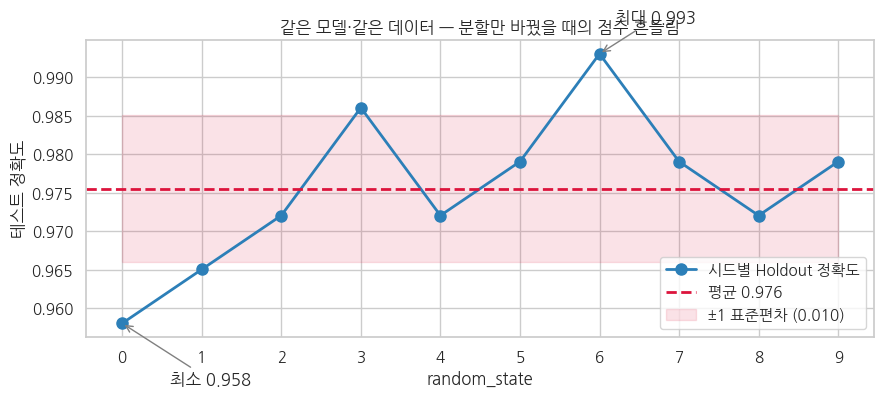

In [4]:
# ─────────────────────────────────────────────
# [C4] Part 1 · 📊 데이터로 확인해 봅시다 — 시드만 바꿔 열 번
# 흔들림을 그림으로 — 점수 분포와 평균±표준편차 (실행하면 그래프가 그려집니다)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.2))

ax.plot(range(10), scores_holdout, "o-", lw=2, markersize=8,
        color="#2c7fb8", label="시드별 Holdout 정확도")
mean_, std_ = scores_holdout.mean(), scores_holdout.std()
ax.axhline(mean_, color="crimson", ls="--", lw=2, label=f"평균 {mean_:.3f}")
ax.fill_between(range(10), mean_ - std_, mean_ + std_, color="crimson", alpha=0.12,
                label=f"±1 표준편차 ({std_:.3f})")
ax.annotate(f"최대 {scores_holdout.max():.3f}",
            xy=(int(np.argmax(scores_holdout)), scores_holdout.max()),
            xytext=(6.2, scores_holdout.max() + 0.004),
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.annotate(f"최소 {scores_holdout.min():.3f}",
            xy=(int(np.argmin(scores_holdout)), scores_holdout.min()),
            xytext=(0.6, scores_holdout.min() - 0.008),
            arrowprops=dict(arrowstyle="->", color="gray"))

ax.set_xlabel("random_state")
ax.set_ylabel("테스트 정확도")
ax.set_title("같은 모델·같은 데이터 — 분할만 바꿨을 때의 점수 흔들림")
ax.set_xticks(range(10))
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("→ 붉은 띠(±1 표준편차) 밖으로 점이 튀어나가는 것을 보세요. 한 점만 보고하면 그 점이 어디였는지에 운이 좌우합니다.")

> 👀 **[C4] 결과읽기**  
> 파란 점들이 시드별 점수이고, 붉은 점선이 평균, 붉은 띠가 ±1 표준편차 구간입니다. 점들이 띠 안에 대체로 머물지만 위아래로 튀어나가는 것이 보입니다.

이 그림이 오늘 Part 4에서 배울 교차검증의 **동기**입니다. 열 번 나눠 재는 것이 한 번 재는 것보다 정직하다면, 아예 그것을 표준 절차로 만들면 됩니다. 교차검증이 정확히 그 일을 합니다 — 다만 더 체계적인 방식으로요.

## ⌨️ 백문이 불여일타! (1)

```
[문제]
[C3]과 같은 실험을 test_size만 바꿔 반복해보세요.

(1) test_size=0.5 (테스트 세트를 절반으로 크게)로 시드 0~9를 돌려
   점수의 폭(최대-최소)과 표준편차를 구해보세요.
2) test_size=0.1 (테스트 세트를 아주 작게)로 같은 것을 구해보세요.
3) 두 결과를 비교하면, 테스트 세트 크기와 점수 흔들림은 어떤 관계입니까?
```

▶️ **코드 실행하기 · 코드 셀 5 [C5]**

In [5]:
# [C5] Part 1 · ⌨️ 백문이 불여일타! (1)
# ⌨️ 백문이 불여일타! (1) — 테스트 세트 크기와 점수 흔들림의 관계

sizes_to_try = [0.5, 0.1]

scores_holdout5 = []
for seed in range(10):
    Xa, Xb, ya, yb = train_test_split(
        X, y, test_size=0.5, random_state=seed, stratify=y)
    m = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    ).fit(Xa, ya)
    scores_holdout5.append(m.score(Xb, yb))

scores_holdout5 = np.array(scores_holdout5)

print("random_state별 테스트 정확도 (사이즈=0.5)")
for seed, s in enumerate(scores_holdout5):
    bar = "█" * int((s - 0.95) * 400)      # 0.95를 기준으로 확대해 차이를 보이게
    print(f"  seed={seed}  {s:.3f}  {bar}")
print()
print(f"최소 {scores_holdout5.min():.3f} / 최대 {scores_holdout5.max():.3f}"
      f" → 폭 {scores_holdout5.max() - scores_holdout5.min():.3f}")
print(f"평균 {scores_holdout5.mean():.3f} ± {scores_holdout5.std():.3f}")
print()
print("→ 모델도 데이터도 똑같습니다. 바꾼 것은 '어떻게 나눌지'뿐입니다.")


scores_holdout1 = []
for seed in range(10):
    Xa, Xb, ya, yb = train_test_split(
        X, y, test_size=0.1, random_state=seed, stratify=y)
    m = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    ).fit(Xa, ya)
    scores_holdout1.append(m.score(Xb, yb))

scores_holdout1 = np.array(scores_holdout1)

print("random_state별 테스트 정확도 (사이즈=0.1)")
for seed, s in enumerate(scores_holdout1):
    bar = "█" * int((s - 0.95) * 400)      # 0.95를 기준으로 확대해 차이를 보이게
    print(f"  seed={seed}  {s:.3f}  {bar}")
print()
print(f"최소 {scores_holdout1.min():.3f} / 최대 {scores_holdout1.max():.3f}"
      f" → 폭 {scores_holdout1.max() - scores_holdout1.min():.3f}")
print(f"평균 {scores_holdout1.mean():.3f} ± {scores_holdout1.std():.3f}")
print()
print("→ 모델도 데이터도 똑같습니다. 바꾼 것은 '어떻게 나눌지'뿐입니다.")

# 여기에 코드를 작성하세요



random_state별 테스트 정확도 (사이즈=0.5)
  seed=0  0.979  ███████████
  seed=1  0.972  ████████
  seed=2  0.972  ████████
  seed=3  0.979  ███████████
  seed=4  0.979  ███████████
  seed=5  0.965  █████
  seed=6  0.972  ████████
  seed=7  0.968  ███████
  seed=8  0.975  ██████████
  seed=9  0.986  ██████████████

최소 0.965 / 최대 0.986 → 폭 0.021
평균 0.975 ± 0.006

→ 모델도 데이터도 똑같습니다. 바꾼 것은 '어떻게 나눌지'뿐입니다.
random_state별 테스트 정확도 (사이즈=0.1)
  seed=0  0.982  ████████████
  seed=1  0.982  ████████████
  seed=2  1.000  ████████████████████
  seed=3  0.982  ████████████
  seed=4  1.000  ████████████████████
  seed=5  0.982  ████████████
  seed=6  0.982  ████████████
  seed=7  0.982  ████████████
  seed=8  0.965  █████
  seed=9  1.000  ████████████████████

최소 0.965 / 최대 1.000 → 폭 0.035
평균 0.986 ± 0.011

→ 모델도 데이터도 똑같습니다. 바꾼 것은 '어떻게 나눌지'뿐입니다.


In [ ]:
# 테스트 세트의 크기가 클수록 분산이 적어진다. 즉 점수의 흔들림이 보정된다

<details>
<summary>(클릭) 💡 힌트</summary>

- [C3]의 반복문을 함수로 감싸면 `test_size`만 바꿔 두 번 호출할 수 있습니다.
- 흔들림의 크기는 `np.std()`로, 폭은 `max() - min()`으로 구합니다.
- 3번은 "테스트 세트가 작으면 한 명을 틀릴 때 정확도가 얼마나 움직이는지"를 생각해보세요.

</details>

## 🚦 짚고 넘어가기

다음 질문에 답할 수 있으면 다음 Part로 넘어가세요. 틀려도 괜찮습니다.

1. 한 번의 Holdout 점수에 섞여 있는 두 가지 요소를 말할 수 있습니까?
2. `0.97 ± 0.01`과 `0.97 ± 0.15`가 어떻게 다른 이야기인지 설명할 수 있습니까?
3. 여러 시드를 돌려보고 가장 높은 점수만 보고하는 것이 왜 문제입니까?

> ⏭️ **다음 학습 예고**  
> 점수가 흔들린다는 것을 알았습니다. 그런데 흔들림보다 더 무서운 문제가 있습니다 — **학습 점수는 완벽한데 테스트 점수만 낮은** 경우입니다. 흔들림은 추정의 문제지만, 이것은 모델 자체의 병입니다. 다음 Part에서 그 병의 이름과 진단법, 그리고 처방까지 봅니다.

# Part 2. 과적합·과소적합 — 편향과 분산

지난 시간에 트리의 깊이를 키우다가 이상한 것을 봤습니다. 학습 정확도가 **1.000**이 됐는데 테스트 정확도는 오히려 떨어졌습니다.

학습 데이터를 100% 맞히는 모델이 왜 나쁜 모델일까요? 이 질문에 답하는 것이 이 Part의 목표입니다.

> ❓ **질문하기**  
> 학습 점수 1.000이 왜 나쁜 신호이고, 그것을 어떻게 진단하고 억제하는가?

## 💡 쉽게 말하면 — 족보를 외운 학생

시험 대비를 하는 두 학생이 있습니다.

**첫 번째 학생**은 개념을 대충만 봤습니다. 어떤 문제를 줘도 비슷하게 틀립니다. 연습문제도 못 풀고 시험도 못 봅니다. 이것이 **과소적합(Underfitting)** 입니다 — 아직 덜 배운 상태입니다.

**두 번째 학생**은 기출문제 500개를 답까지 통째로 외웠습니다. 연습문제는 100% 맞힙니다. 그런데 시험에서 숫자만 살짝 바뀐 문제가 나오자 무너집니다. 이것이 **과적합(Overfitting)** 입니다 — 패턴이 아니라 **답을 외운** 상태입니다.

그림으로 보면 이렇습니다.

![과적합 도해 — 두 색의 점을 가르는 경계로, 매끄러운 검은 곡선과 모든 점을 하나하나 감싸려 심하게 구불거리는 초록 곡선이 함께 그려져 있다](https://upload.wikimedia.org/wikipedia/commons/1/19/Overfitting.svg)

_(출처: [Overfitting](https://commons.wikimedia.org/wiki/File:Overfitting.svg) — Chabacano, CC BY-SA 4.0)_

> 👀 **[C5] 결과읽기**  
> 두 곡선 모두 두 색의 점을 가르는 경계입니다. **검은 곡선**은 매끄럽게 큰 흐름만 잡았고, **초록 곡선**은 점 하나하나를 놓치지 않으려고 심하게 구불거립니다. 학습 데이터에서는 초록이 더 정확합니다 — 실제로 모든 점을 맞힙니다. 그런데 새 점이 하나 추가되면? 초록의 구불거림은 **그 데이터에만 있던 잡음을 외운 것**이라 새 점에서는 오히려 틀립니다. 검은 곡선이 더 잘 일반화합니다.

**핵심은 이것입니다 — 학습 데이터를 완벽히 맞히는 것은 목표가 아닙니다.** 우리의 목표는 처음 보는 데이터를 맞히는 것이고, 그 능력을 **일반화(Generalization)** 라고 부릅니다.

## 🔍 자세히 알아보기 — 편향과 분산, 그리고 총오차

과적합과 과소적합을 하나의 틀로 설명하는 개념이 있습니다. **편향-분산 트레이드오프**입니다.

- **편향(Bias)** — 모델이 너무 단순해서 진짜 패턴을 담지 못하는 정도. 직선으로 곡선을 표현하려 할 때 생기는 구조적 오차입니다.
- **분산(Variance)** — 학습 데이터가 조금 바뀔 때 모델이 크게 흔들리는 정도. 복잡한 모델일수록 데이터의 잡음까지 따라갑니다.

모델의 총오차는 대략 이렇게 분해됩니다.

$$\text{총오차} \approx \text{편향}^2 + \text{분산} + \text{잡음}$$

- $\text{편향}^2$ — 모델이 단순해서 생기는 오차. 복잡도를 키우면 **줄어듭니다**
- $\text{분산}$ — 모델이 흔들려서 생기는 오차. 복잡도를 키우면 **늘어납니다**
- $\text{잡음}$ — 데이터 자체에 있는 줄일 수 없는 오차 (측정 한계 등)

앞의 두 항이 **서로 반대 방향으로 움직인다**는 것이 핵심입니다. 그래서 총오차는 U자를 그리고, 그 바닥에 최적 복잡도가 있습니다.

![편향-분산 트레이드오프 곡선 — 가로축 모델 복잡도, 세로축 오차. 편향의 제곱은 감소하고 분산은 증가하며, 둘의 합인 총오차는 U자를 그려 중간에 최소점을 가진다](https://upload.wikimedia.org/wikipedia/commons/9/9f/Bias_and_variance_contributing_to_total_error.svg)

_(출처: [Bias and variance contributing to total error](https://commons.wikimedia.org/wiki/File:Bias_and_variance_contributing_to_total_error.svg) — Bigbossfarin, CC0)_

> 👀 **[C5] 결과읽기**  
> 가로축이 **모델 복잡도**, 세로축이 **오차**입니다. 붉은 선(편향²)은 오른쪽으로 갈수록 내려가고, 청록 선(분산)은 올라갑니다. 둘을 합한 검은 선(총오차)이 **U자**를 그리며, 그 바닥이 점선으로 표시된 **최적 복잡도**입니다. 왼쪽 영역이 과소적합, 오른쪽 영역이 과적합입니다.

### 진단표 — 두 점수의 관계로 읽는다

이론은 그렇고, 실제로는 **두 숫자만 보면** 진단이 됩니다.

| 학습 점수     | 테스트 점수 | 진단                    | 처방                          |
| ------------- | ----------- | ----------------------- | ----------------------------- |
| 낮음          | 낮음        | 😵 **과소적합** (편향↑) | 복잡도↑, 피처 추가, 다른 모델 |
| 높음          | 높음        | 👍 **적정**             | 유지                          |
| **매우 높음** | **낮음**    | ⚠️ **과적합** (분산↑)   | 복잡도↓, **규제**, 데이터↑    |

> ⚠️ **주의하기**  
> "격차가 몇 이상이면 과적합"이라는 절대 기준은 없습니다. 데이터 크기·문제 난이도·지표에 따라 다르므로, **같은 문제 안에서 여러 설정을 비교**해 판단합니다. 오늘 익힐 것은 숫자 기준이 아니라 *두 점수를 항상 나란히 본다*는 습관입니다.

> 📌 **실무 연결하기**  
> 과적합은 **금융** 신용평가(과거 고객엔 맞는데 신규 고객엔 틀림), **제조** 품질 예측(특정 라인·시기에만 맞음), **헬스케어** 진단 모델(한 병원 데이터로 학습해 다른 병원에서 무너짐)에서 똑같이 나타납니다. 특히 마지막 경우를 **외부 검증 실패**라 부르며, 논문으로 발표된 의료 AI가 현장에서 재현되지 않는 가장 흔한 원인입니다.

## 📊 데이터로 확인해 봅시다 — 과적합이 태어나는 장면

트리의 깊이를 1부터 키우며 학습 점수와 테스트 점수를 나란히 봅니다. 지난 시간에 스쳐 지나간 그 현상을 이번엔 정면으로 봅니다.

> 🤔 **예상하기**  
> 의사결정나무의 깊이를 계속 키우면 **학습 정확도**는 어디까지 갈까요? 그리고 그때 **테스트 정확도**는 함께 올라갈까요, 어느 지점에서 꺾일까요? 꺾인다면 몇 번째 깊이쯤일 것 같습니까?

▶️ **코드 실행하기 · 코드 셀 6 [C6]**

In [6]:
# ─────────────────────────────────────────────
# [C6] Part 2 · 📊 데이터로 확인해 봅시다 — 과적합이 태어나는 장면
# 트리 깊이를 키우며 학습/테스트 점수 추적 (실행하면 깊이별 격차 표가 나옵니다)
# ─────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier

depths = [1, 2, 3, 5, 8, 12, None]

rows = []
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    tr = tree.score(X_train, y_train)
    te = tree.score(X_test, y_test)
    rows.append({
        "max_depth": "제한 없음" if d is None else d,
        "학습 점수": tr,
        "테스트 점수": te,
        "격차": tr - te,
        "실제 깊이": tree.get_depth(),
    })
gap = pd.DataFrame(rows)
print(gap.round(3).to_string(index=False))
print()
best = gap.loc[gap["테스트 점수"].idxmax()]
print(f"→ 테스트 점수가 가장 높은 설정: max_depth={best['max_depth']} (테스트 {best['테스트 점수']:.3f})")
print(f"  학습 점수가 1.000이 되는 지점부터 테스트는 {gap['테스트 점수'].iloc[-1]:.3f}에 머물고 격차만 벌어집니다.")

max_depth  학습 점수  테스트 점수     격차  실제 깊이
        1  0.923   0.923 -0.001      1
        2  0.958   0.909  0.049      2
        3  0.977   0.944  0.032      3
        5  0.995   0.937  0.058      5
        8  1.000   0.923  0.077      7
       12  1.000   0.923  0.077      7
    제한 없음  1.000   0.923  0.077      7

→ 테스트 점수가 가장 높은 설정: max_depth=3 (테스트 0.944)
  학습 점수가 1.000이 되는 지점부터 테스트는 0.923에 머물고 격차만 벌어집니다.


> 🎯 **[C6] 확인하기**  
> 학습 점수는 **1.000까지 갑니다.** 깊이 8부터는 학습 데이터를 완벽히 맞힙니다.

그런데 테스트 점수를 보세요.

| max_depth | 학습      | 테스트    | 격차       |
| --------- | --------- | --------- | ---------- |
| 1         | 0.923     | 0.923     | **−0.001** |
| 3         | 0.977     | **0.944** | +0.032     |
| 5         | 0.995     | 0.937     | +0.058     |
| 8 이상    | **1.000** | 0.923     | **+0.077** |

**이 Holdout 분할에서는 깊이 3의 테스트 점수(0.944)가 가장 높습니다.** 그 뒤로는 학습 점수만 계속 오르고 테스트 점수는 오히려 떨어집니다. 깊이 8 이상에서는 학습 데이터를 완벽히 맞혔지만 테스트 점수는 깊이 1과 같은 0.923입니다. 이 분할만으로 최적 깊이를 확정할 수는 없지만, 적어도 **복잡도를 더 키울 근거는 없다**는 신호입니다.

깊이 1에서 격차가 **−0.001**(테스트가 아주 조금 더 높음)인 것도 눈여겨보세요. 이 작은 차이 하나만으로 과소적합을 단정할 수는 없지만, 학습·테스트 점수가 모두 상대적으로 낮고 복잡도를 키웠을 때 검증 성능이 좋아지는 흐름은 모델이 너무 단순했을 가능성을 뒷받침합니다.

> 💡 **핵심짚기**  
> 학습 점수 1.000은 자랑이 아니라 **경고 신호**입니다. 그것은 "잘 배웠다"가 아니라 "외웠을 수도 있다"는 뜻이며, 반드시 테스트 점수와 나란히 놓고 판단해야 합니다.

▶️ **코드 실행하기 · 코드 셀 7 [C7]**

→ 붉은 영역이 넓어지는 것이 곧 과적합이 자라는 모습입니다.
  녹색 점선 왼쪽은 과소적합 영역, 오른쪽은 과적합 영역입니다.


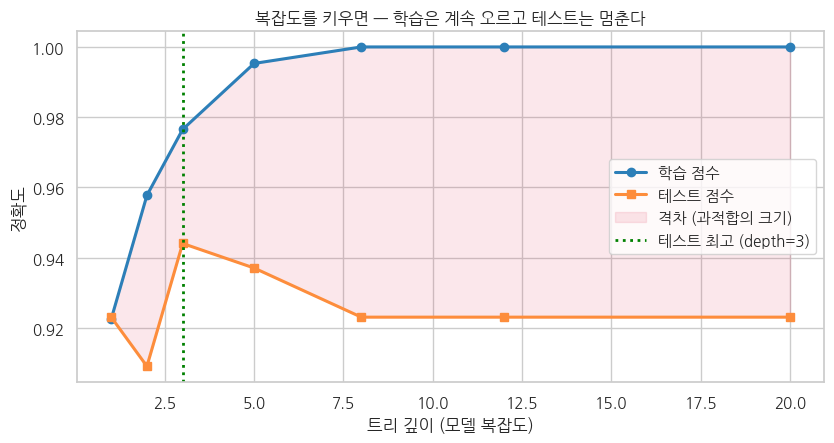

In [7]:
# ─────────────────────────────────────────────
# [C7] Part 2 · 📊 데이터로 확인해 봅시다 — 과적합이 태어나는 장면
# 격차가 벌어지는 모습을 그림으로 (실행하면 두 곡선과 격차 영역이 그려집니다)
# ─────────────────────────────────────────────
plot_depths = [1, 2, 3, 5, 8, 12, 20]
tr_scores, te_scores = [], []
for d in plot_depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(X_train, y_train)
    tr_scores.append(t.score(X_train, y_train))
    te_scores.append(t.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(plot_depths, tr_scores, "o-", lw=2.2, color="#2c7fb8", label="학습 점수")
ax.plot(plot_depths, te_scores, "s-", lw=2.2, color="#fd8d3c", label="테스트 점수")
ax.fill_between(plot_depths, te_scores, tr_scores, color="crimson", alpha=0.10,
                label="격차 (과적합의 크기)")
best_i = int(np.argmax(te_scores))
ax.axvline(plot_depths[best_i], color="green", ls=":", lw=2,
           label=f"테스트 최고 (depth={plot_depths[best_i]})")
ax.set_xlabel("트리 깊이 (모델 복잡도)")
ax.set_ylabel("정확도")
ax.set_title("복잡도를 키우면 — 학습은 계속 오르고 테스트는 멈춘다")
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

print("→ 붉은 영역이 넓어지는 것이 곧 과적합이 자라는 모습입니다.")
print(f"  녹색 점선 왼쪽은 과소적합 영역, 오른쪽은 과적합 영역입니다.")

> 👀 **[C7] 결과읽기**  
> 파란 선(학습)은 천장을 향해 계속 오르고, 주황 선(테스트)은 깊이 3 근처에서 꺾입니다. 두 선 사이의 **붉은 영역이 넓어지는 것이 곧 과적합이 자라는 모습**입니다.

앞서 본 편향-분산 곡선의 U자를 이 그림과 겹쳐보세요. 녹색 점선이 그 U자의 바닥, 즉 **최적 복잡도**에 해당합니다. 왼쪽은 편향이 지배하는 과소적합 영역, 오른쪽은 분산이 지배하는 과적합 영역입니다.

그럼 과적합을 발견했을 때 무엇을 할 수 있을까요? 복잡도를 줄이는 것(깊이 제한)은 이미 봤습니다. 그 외에 **모델의 복잡도를 부드럽게 억제하는** 방법이 하나 더 있습니다 — **규제(Regularization)** 입니다.

**규제는 "모델이 과하게 복잡해지면 벌점을 매기는" 장치입니다.** 트리에서는 깊이를 잘라 복잡도를 줄였는데, 선형 모델에는 깊이가 없습니다. 대신 **계수의 크기**가 복잡도 역할을 합니다 — 계수가 크다는 건 "이 피처가 조금만 변해도 예측이 크게 흔들린다"는 뜻이니까요. 그래서 손실 함수에 계수 크기만큼 벌점을 얹으면, 모델은 꼭 필요한 만큼만 계수를 키웁니다.

벌점을 매기는 방식에 따라 두 갈래로 나뉘고, 이름을 알아 둘 만합니다.

|           | **Ridge**(L2)         | **Lasso**(L1)              |
| --------- | --------------------- | -------------------------- |
| 벌점 계산 | 계수의 **제곱** 합    | 계수의 **절댓값** 합       |
| 계수를    | 0에 **가깝게** 줄임   | **정확히 0**으로 만듦      |
| 그래서    | 모든 피처를 조금씩 씀 | **피처를 자동으로 골라냄** |

Part 2와 Part 3의 진단표에서 처방 칸에 적힌 **"규제"** 가 바로 이것입니다. 벌점의 세기를 직접 돌려 가며 두 방식의 차이를 눈으로 확인하는 실습은 아래 선택 학습에 있습니다.

## ➕ 더 알고 싶다면 — 규제(Regularization)로 과적합 억제

여기서부터는 **선택 학습**입니다. 오늘의 핵심(진단과 교차검증)에는 포함되지 않지만, 실무에서 과적합 처방으로 가장 널리 쓰이는 도구이므로 한 번 보고 넘어가면 좋습니다. 시간이 빡빡하면 건너뛰고 Part 3으로 가도 괜찮습니다.

### 계수에 매기는 벌금

트리는 깊이를 잘라 복잡도를 줄였습니다. 그런데 선형 모델에는 '깊이'가 없습니다. 대신 **계수의 크기**가 복잡도 역할을 합니다.

계수가 크다는 것은 "이 피처가 조금만 변해도 예측이 크게 흔들린다"는 뜻입니다. 그런 모델은 학습 데이터의 잡음에 민감하게 반응합니다. 그래서 **손실 함수에 계수 크기만큼 벌금을 매기면**, 모델은 꼭 필요한 만큼만 계수를 키우게 됩니다. 이것이 **규제**입니다.

$$\text{최소화 대상} = \text{원래 손실} + \alpha \times (\text{계수 크기 벌금})$$

- $\alpha$ — 벌금의 세기. 크면 강한 규제(단순한 모델), 작으면 약한 규제(복잡한 모델)
- 벌금을 계수의 **제곱** 합으로 매기면 **Ridge**(L2), **절댓값** 합으로 매기면 **Lasso**(L1)

scikit-learn의 `LogisticRegression`은 벌금 세기를 `C`로 지정하는데, **`C`는 $\alpha$의 역수**입니다. 즉 **`C`가 작을수록 규제가 강합니다.** 헷갈리기 쉬운 지점이니 기억해 두세요.

▶️ **코드 실행하기 · 코드 셀 8 [C8]**

In [8]:
# ─────────────────────────────────────────────
# [C8] Part 2 · ➕ 더 알고 싶다면 — 규제(Regularization)로 과적합 억제
# 규제 세기 C를 바꿔가며 학습/테스트 점수와 계수 크기 관찰 (실행하면 표가 나옵니다)
# ─────────────────────────────────────────────
rows = []
for C_val in [0.001, 0.01, 0.1, 1, 10, 100]:
    m = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=C_val, max_iter=5000, random_state=RANDOM_STATE),
    ).fit(X_train, y_train)
    coef = m.named_steps["logisticregression"].coef_[0]
    rows.append({
        "C (작을수록 강한 규제)": C_val,
        "학습 점수": m.score(X_train, y_train),
        "테스트 점수": m.score(X_test, y_test),
        "|계수| 합": np.abs(coef).sum(),
    })
reg = pd.DataFrame(rows)
print(reg.round(3).to_string(index=False))
print()
best = reg.loc[reg["테스트 점수"].idxmax()]
print(f"→ 테스트 최고: C={best['C (작을수록 강한 규제)']} (테스트 {best['테스트 점수']:.3f})")
print("  규제를 풀면(C↑) 계수가 커지고 학습 점수는 오르지만 테스트는 떨어집니다.")

 C (작을수록 강한 규제)  학습 점수  테스트 점수  |계수| 합
          0.001  0.892   0.916   1.390
          0.010  0.958   0.937   3.949
          0.100  0.984   0.979   8.599
          1.000  0.988   0.986  16.789
         10.000  0.991   0.972  35.230
        100.000  0.998   0.944 114.147

→ 테스트 최고: C=1.0 (테스트 0.986)
  규제를 풀면(C↑) 계수가 커지고 학습 점수는 오르지만 테스트는 떨어집니다.


> 👀 **[C8] 결과읽기**  
> 세 열이 함께 움직이는 방향을 보세요.

| C     | 학습      | 테스트    | \|계수\| 합 | 상태                        |
| ----- | --------- | --------- | ----------- | --------------------------- |
| 0.001 | 0.892     | 0.916     | **1.39**    | 과소적합 (벌금이 너무 세다) |
| 1     | 0.988     | **0.986** | 16.79       | **적정**                    |
| 100   | **0.998** | 0.944     | **114.15**  | 과적합 (벌금이 거의 없다)   |

`C`를 0.001에서 100으로 키우면 계수 합이 **1.39에서 114.15로 82배** 커집니다. 그와 함께 학습 점수는 0.892 → 0.998로 계속 오르지만, 테스트 점수는 0.916 → 0.986 → 0.944로 **U자를 그립니다.** [C7]의 트리 깊이 그래프와 똑같은 모양입니다 — 복잡도의 손잡이만 '깊이'에서 '계수 크기'로 바뀐 것입니다.

### Ridge와 Lasso의 결정적 차이

벌금을 매기는 방식이 다르면 결과도 달라집니다. **Lasso(L1)는 계수를 정확히 0으로 만들 수 있고, Ridge(L2)는 0에 가깝게만 줄입니다.**

▶️ **코드 실행하기 · 코드 셀 9 [C9]**

In [9]:
# ─────────────────────────────────────────────
# [C9] Part 2 · ➕ 더 알고 싶다면 — 규제(Regularization)로 과적합 억제
# L1(Lasso) vs L2(Ridge) — 계수가 0이 되는 개수 비교 (실행하면 비교표가 나옵니다)
# ─────────────────────────────────────────────
rows = []
for C_val in [0.001, 0.01, 0.1, 1, 10]:
    out = {"C": C_val}
    # l1_ratio=1 → L1(Lasso), 0 → L2(Ridge). 구 penalty= 인자는 sklearn 1.10에서 제거됩니다
    for l1_ratio, label in [(1.0, "L1(Lasso)"), (0.0, "L2(Ridge)")]:
        m = make_pipeline(
            StandardScaler(),
            LogisticRegression(C=C_val, l1_ratio=l1_ratio, solver="saga",
                               max_iter=20000, random_state=RANDOM_STATE),
        ).fit(X_train, y_train)
        coef = m.named_steps["logisticregression"].coef_[0]
        out[f"{label} 0인 피처"] = int((np.abs(coef) < 1e-8).sum())
        out[f"{label} 테스트"] = m.score(X_test, y_test)
    rows.append(out)
paths = pd.DataFrame(rows)
print(f"전체 피처 {X.shape[1]}개 중 계수가 0이 된 개수")
print()
print(paths.round(3).to_string(index=False))
print()
print("→ L1은 규제를 세게 걸수록 많은 피처를 '완전히 끕니다'(계수 0). L2는 한 개도 끄지 않습니다.")

전체 피처 30개 중 계수가 0이 된 개수

     C  L1(Lasso) 0인 피처  L1(Lasso) 테스트  L2(Ridge) 0인 피처  L2(Ridge) 테스트
 0.001                0          0.916                0          0.916
 0.010                0          0.937                0          0.937
 0.100                0          0.979                0          0.979
 1.000                0          0.986                0          0.986
10.000                0          0.972                0          0.972

→ L1은 규제를 세게 걸수록 많은 피처를 '완전히 끕니다'(계수 0). L2는 한 개도 끄지 않습니다.


> 👀 **[C9] 결과읽기**  
> 30개 피처 중 계수가 정확히 0이 된 개수입니다.

| C     | L1이 끈 피처    | L1 테스트 | L2가 끈 피처 | L2 테스트 |
| ----- | --------------- | --------- | ------------ | --------- |
| 0.001 | **30개** (전부) | 0.629     | 0개          | 0.916     |
| 0.1   | 23개            | 0.965     | 0개          | 0.979     |
| 1     | 14개            | **0.993** | 0개          | 0.986     |
| 10    | 4개             | 0.979     | 0개          | 0.972     |

**L1은 피처를 자동으로 골라냅니다.** `C=1`에서 30개 중 14개를 완전히 끄고도 테스트 정확도 0.993을 냈습니다 — 절반 이하의 피처로 같거나 더 좋은 성능입니다. 그래서 Lasso를 **자동 피처 선택** 도구로도 씁니다.

반면 **L2는 단 한 개도 끄지 않습니다.** 모든 피처를 조금씩 줄여 함께 씁니다.

`C=0.001`에서 L1이 30개 전부를 끈 것도 보세요. 계수가 모두 0이면 남는 것은 절편뿐이라, 모델은 **무조건 다수 클래스로 찍는 것과 똑같아집니다.** 그때 테스트 정확도가 **0.629** — 정확히 테스트셋의 다수 클래스 비율입니다. 규제도 지나치면 모델을 베이스라인으로 되돌린다는 뜻입니다.

|              | Ridge (L2)                    | Lasso (L1)                   |
| ------------ | ----------------------------- | ---------------------------- |
| 계수를       | 0에 가깝게 줄임               | **정확히 0**으로 만듦        |
| 피처 선택    | 안 함                         | **자동으로 함**              |
| 쓰기 좋은 때 | 피처가 대체로 다 쓸모 있을 때 | 피처가 많고 일부만 중요할 때 |

> 📌 **규제는 어디에나 있습니다:**  
> 오늘은 선형 모델로 배웠지만 같은 아이디어가 전방위로 쓰입니다 — 트리의 `max_depth`·`min_samples_leaf`, 부스팅의 `learning_rate`, 신경망의 Dropout·Weight Decay가 모두 "모델이 과하게 복잡해지는 것을 억제하는" 규제 장치입니다. **규제는 특정 알고리즘의 옵션이 아니라 머신러닝 전반의 설계 원리입니다.**

여기까지가 선택 학습이었습니다. 이제 본 줄기로 돌아갑니다.

## ⌨️ 백문이 불여일타! (2)

```
[문제]
[C6]에서 트리 깊이로 과적합을 봤습니다. 이번엔 다른 손잡이를 써보세요.

1) DecisionTreeClassifier의 min_samples_leaf를 1, 5, 10, 30, 50으로 바꿔가며
   학습 점수·테스트 점수·격차를 표로 출력해보세요. (max_depth는 주지 마세요)
2) 격차가 가장 작은 설정과 테스트 점수가 가장 높은 설정을 각각 찾아보세요.
   두 설정이 같습니까?
3) min_samples_leaf를 키우는 것이 왜 과적합을 억제하는지 한 줄로 설명해보세요.
```

▶️ **코드 실행하기 · 코드 셀 10 [C10]**

In [10]:
# [C10] Part 2 · ⌨️ 백문이 불여일타! (2)
# ⌨️ 백문이 불여일타! (2) — 다른 손잡이(min_samples_leaf)로 과적합 억제

leaf_sizes = [1, 5, 10, 30, 50]

rows = []
for l in leaf_sizes:
    tree = DecisionTreeClassifier(min_samples_leaf=l, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    tr = tree.score(X_train, y_train)
    te = tree.score(X_test, y_test)
    rows.append({
        "min_samples_leaf": l,
        "학습 점수": tr,
        "테스트 점수": te,
        "격차": tr - te,
        "실제 깊이": tree.get_depth(),
    })
gap = pd.DataFrame(rows)
print(gap.round(3).to_string(index=False))
print()
best = gap.loc[gap["테스트 점수"].idxmax()]
small = gap.loc[gap["격차"].idxmin()]
print(f"→ 테스트 점수가 가장 높은 설정: min_samples_leaf={best['min_samples_leaf']} (테스트 {best['테스트 점수']:.3f})")
print(f"-> 격차가 가장 작은 설정: min_samples_leaf={small['min_samples_leaf']} (격차 {small['격차']:.3f})")

# 잎 최소 샘플수를 키우면 흔들림이 보정되기 때문에 과적합이 억제된다.
# 여기에 코드를 작성하세요

 min_samples_leaf  학습 점수  테스트 점수     격차  실제 깊이
                1  1.000   0.923  0.077      7
                5  0.977   0.930  0.046      6
               10  0.962   0.951  0.011      5
               30  0.946   0.916  0.030      4
               50  0.923   0.923 -0.001      3

→ 테스트 점수가 가장 높은 설정: min_samples_leaf=10.0 (테스트 0.951)
-> 격차가 가장 작은 설정: min_samples_leaf=50.0 (격차 -0.001)


<details>
<summary>(클릭) 💡 힌트</summary>

- `DecisionTreeClassifier(min_samples_leaf=n, random_state=RANDOM_STATE)`로 만들어 [C6]과 같은 방식으로 재세요.
- 표로 만들려면 결과를 딕셔너리 목록에 모아 `pd.DataFrame(...)`으로 감싸면 됩니다.
- 3번은 이 옵션의 뜻을 생각해보세요 — "잎 하나에 최소 몇 개의 표본이 있어야 하는가"입니다.

</details>

## 🚦 짚고 넘어가기

1. 학습 점수 1.000을 보고 무엇을 먼저 확인해야 합니까?
2. 편향과 분산이 복잡도에 대해 각각 어떻게 움직이는지 설명할 수 있습니까?
3. "격차를 최소화하는 것"이 목표가 아닌 이유는 무엇입니까?

> ⏭️ **다음 학습 예고**  
> 과적합을 진단하는 도구 하나(학습/테스트 격차)를 얻었습니다. 그런데 이 도구는 "지금 과적합인가"만 알려주고 **"그래서 무엇을 해야 하는가"** 에는 답하지 않습니다. 데이터를 더 모아야 할까요, 모델을 바꿔야 할까요? 다음 Part에서 그 판단을 가능하게 하는 두 번째 진단 도구를 배웁니다.

# Part 3. 학습곡선 — 데이터를 더 모을까, 모델을 바꿀까

과적합을 발견했습니다. 그런데 발견 다음에는 반드시 **행동**이 와야 합니다. 실무에서 이 순간의 선택은 대개 둘 중 하나입니다.

- **"데이터를 더 모으자"** — 시간과 비용이 듭니다. 라벨링 작업이 필요할 수도 있습니다.
- **"모델·피처를 바꾸자"** — 분석가의 시간이 듭니다.

둘 다 비쌉니다. 그리고 **틀린 쪽을 고르면 그 비용이 전부 낭비**됩니다. 데이터를 더 모아도 성능이 오르지 않는 상황에서 6개월간 데이터를 수집하는 일이 현장에서 실제로 벌어집니다.

이 선택을 근거 있게 하는 도구가 있습니다.

> ❓ **질문하기**  
> 데이터를 더 모을 가치가 있는지, 그림 하나로 어떻게 판단하는가?

## 💡 쉽게 말하면 — 운동의 성장 곡선

운동을 처음 시작하면 실력이 빠르게 늡니다. 한 달 만에 눈에 보이는 변화가 옵니다. 그런데 몇 년 하면 곡선이 완만해집니다. 같은 노력을 들여도 나아지는 폭이 줄어듭니다.

이때 판단이 갈립니다. 아직 **가파르게 오르는 구간**이라면 "그냥 더 하면 된다"가 맞습니다. 이미 **평평해진 구간**이라면 "더 하는 것보다 방법을 바꿔야 한다"가 맞습니다.

학습곡선(Learning Curve)이 정확히 이 그림입니다. 가로축이 **학습에 쓴 데이터 양**, 세로축이 **점수**입니다. 데이터를 조금씩 늘려가며 점수가 어떻게 변하는지 그려서, 지금이 어느 구간인지 봅니다.

![K-Fold 교차검증 도해 — 전체 데이터를 k개 조각으로 나누고, 각 반복(Iteration)마다 서로 다른 한 조각을 테스트로 쓰고 나머지를 학습에 쓴다](https://upload.wikimedia.org/wikipedia/commons/b/b5/K-fold_cross_validation_EN.svg)

_(출처: [K-fold cross validation EN](https://commons.wikimedia.org/wiki/File:K-fold_cross_validation_EN.svg) — Gufosowa, CC BY-SA 4.0)_

> 👀 **[C10] 결과읽기**  
> 이 그림은 다음 Part의 주제이지만, 학습곡선을 그릴 때도 같은 장치를 씁니다. **각 데이터 양마다 여러 번 나눠 재야** 곡선의 각 점이 믿을 만해지기 때문입니다. `learning_curve`는 내부에서 이 교차검증을 자동으로 돌립니다. Iteration마다 검은 테두리(테스트 조각)가 옮겨 다니는 것을 보세요 — 모든 데이터가 한 번씩 평가에 쓰입니다.

## 🔍 자세히 알아보기 — 곡선의 모양이 처방을 정한다

학습곡선에는 **두 개의 선**이 그려집니다.

- **학습 점수 곡선** — 학습에 쓴 데이터에서의 점수. 보통 데이터가 늘면 조금 **내려갑니다**(외우기 어려워지므로)
- **검증 점수 곡선** — 처음 보는 데이터에서의 점수. 데이터가 늘면 **올라갑니다**

이 두 선의 **최종 위치와 간격**으로 처방이 결정됩니다.

| 곡선의 모양                                     | 진단                                    | 처방                                 |
| ----------------------------------------------- | --------------------------------------- | ------------------------------------ |
| 검증 곡선이 **아직 가파르게 오르는 중**         | 데이터 부족                             | ✅ **데이터를 더 모아라**            |
| 검증 곡선이 **평평해졌고** 학습과의 격차도 작음 | 현재 설정에서 추가 데이터의 이득이 작음 | ✅ 피처·모델·문제 정의를 우선 점검   |
| 검증 곡선이 평평하지만 **학습과 격차가 큼**     | 과적합                                  | ✅ **규제·복잡도↓** 또는 데이터 추가 |
| 두 곡선이 **낮은 곳에서 붙어 있음**             | 과소적합                                | ✅ **복잡도↑, 피처 추가**            |

핵심 판단 기준은 **"검증 곡선의 오른쪽 끝이 아직 오르고 있는가"** 입니다.

- 아직 오르고 있다면 → 데이터를 더 모으면 그만큼 이득이 옵니다
- 평평해졌다면 → 데이터를 두 배로 늘려도 거의 그대로입니다. 돈과 시간을 버리는 것입니다

> ⚠️ **주의하기**  
> 학습곡선의 각 점은 **여러 번 나눠 잰 평균**이어야 합니다. 한 번씩만 재면 Part 1에서 본 분할 운 때문에 곡선이 들쭉날쭉해져 판단할 수 없습니다. `learning_curve(..., cv=...)`에 교차검증 객체를 넘기는 이유입니다.

> 📌 **실무 연결하기**  
> 이 판단은 곧 예산 결정입니다 — **헬스케어**에서 환자 데이터를 더 모으려면 임상 절차와 윤리 심의가 필요하고, **제조**에서 불량 데이터를 늘리려면 실제로 불량을 더 만들어야 하며, **금융**에서는 시간이 지나야 부도 이력이 쌓입니다. 어느 쪽이든 "데이터를 더 모으자"는 결정 전에 학습곡선 한 장을 보는 것이 훨씬 쌉니다.

## 📊 데이터로 확인해 봅시다 — 우리 데이터는 어느 구간인가

유방암 데이터로 학습곡선을 그려봅니다. 전체 569명 중 10%부터 100%까지 여섯 단계로 늘려가며, 각 단계에서 계층 5겹 교차검증으로 점수를 잽니다.

> 🤔 **예상하기**  
> 569명은 머신러닝 기준으로 많은 편이 아닙니다. 그렇다면 이 데이터의 검증 곡선은 오른쪽 끝에서 **아직 오르고 있을까요, 평평해졌을까요?** 즉 "환자 데이터를 더 모으자"는 제안에 여러분은 찬성하겠습니까?

▶️ **코드 실행하기 · 코드 셀 11 [C11]**

In [11]:
# ─────────────────────────────────────────────
# [C11] Part 3 · 📊 데이터로 확인해 봅시다 — 우리 데이터는 어느 구간인가
# 학습곡선 계산 — 데이터 양을 늘려가며 학습/검증 점수 (실행하면 단계별 표가 나옵니다)
# ─────────────────────────────────────────────
from sklearn.model_selection import learning_curve
from sklearn.model_selection import StratifiedKFold

model_lc = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
)

train_sizes, train_scores, val_scores = learning_curve(
    model_lc, X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.1, 1.0, 6),
    scoring="accuracy",
)

lc = pd.DataFrame({
    "학습 표본 수": train_sizes.astype(int),
    "학습 점수": train_scores.mean(axis=1),
    "검증 점수": val_scores.mean(axis=1),
})
lc["격차"] = lc["학습 점수"] - lc["검증 점수"]
lc["검증 점수 증가분"] = lc["검증 점수"].diff().fillna(0)

print(lc.round(3).to_string(index=False))
print()
last_gain = lc["검증 점수 증가분"].iloc[-1]
print(f"→ 마지막 구간(표본 {int(train_sizes[-2])}→{int(train_sizes[-1])})의 검증 점수 변화: {last_gain:+.3f}")
print("  이 값이 0에 가까우면 '데이터를 더 모아도 이득이 거의 없다'는 신호입니다.")

 학습 표본 수  학습 점수  검증 점수    격차  검증 점수 증가분
      45  0.987  0.859 0.127      0.000
     127  0.983  0.954 0.028      0.095
     209  0.987  0.970 0.016      0.016
     291  0.982  0.967 0.015     -0.004
     373  0.987  0.977 0.010      0.011
     455  0.988  0.974 0.014     -0.004

→ 마지막 구간(표본 373→455)의 검증 점수 변화: -0.004
  이 값이 0에 가까우면 '데이터를 더 모아도 이득이 거의 없다'는 신호입니다.


> 🎯 **[C11] 확인하기**  
> 곡선은 **이미 평평해졌습니다.**

| 학습 표본 | 학습 점수 | 검증 점수 | 격차   |
| --------- | --------- | --------- | ------ |
| 45        | 0.987     | **0.859** | +0.127 |
| 127       | 0.983     | 0.954     | +0.028 |
| 209       | 0.987     | 0.970     | +0.016 |
| 373       | 0.987     | 0.977     | +0.010 |
| 455       | 0.988     | 0.974     | +0.014 |

초반이 극적입니다. 표본 45명에서 검증 점수가 **0.859**, 격차가 **+0.127** — 데이터가 너무 적어 심하게 과적합된 상태입니다. 그런데 127명으로만 늘려도 검증이 0.954로 뛰고 격차가 +0.028로 줄어듭니다. **초반 데이터 추가는 효과가 엄청납니다.**

그런데 209명 이후를 보세요. 0.970 → 0.977 → 0.974로 **거의 움직이지 않습니다.** 마지막 구간에서는 오히려 살짝 내려갔습니다(측정 흔들림 범위 안입니다).

**그래서 판단은 이렇습니다 — "환자 데이터를 더 모으자"는 제안에는 반대해야 합니다.** 200명 수준에서 이미 이 모델의 한계에 도달했고, 300명을 더 모아도 검증 점수는 0.98 근처에 머물 것입니다. 성능을 더 올리려면 **데이터 양이 아니라 다른 것**을 바꿔야 합니다 — 새로운 종류의 피처, 더 표현력 있는 모델, 또는 문제 정의 자체입니다.

▶️ **코드 실행하기 · 코드 셀 12 [C12]**

→ 주황 선(검증)의 오른쪽 끝이 평평하면 데이터 추가의 이득이 거의 없다는 뜻입니다.


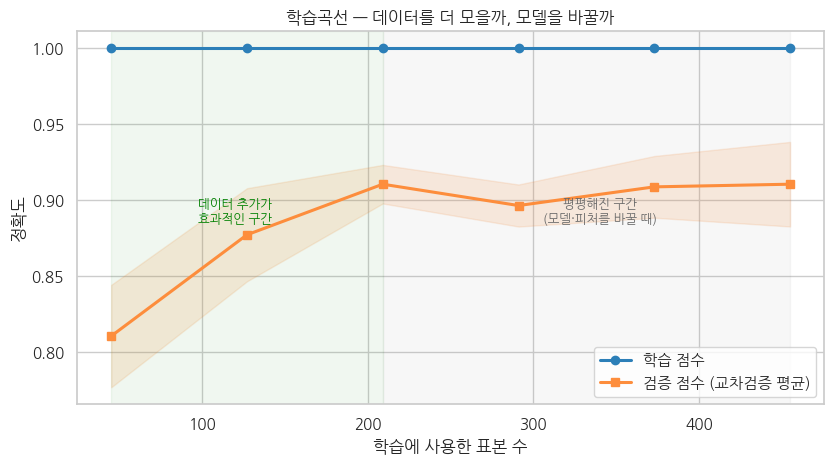

In [13]:
# ─────────────────────────────────────────────
# [C12] Part 3 · 📊 데이터로 확인해 봅시다 — 우리 데이터는 어느 구간인가
# 학습곡선 그리기 — 흔들림 범위까지 함께 (실행하면 두 곡선과 신뢰 띠가 그려집니다)
# ─────────────────────────────────────────────
tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
va_mean, va_std = val_scores.mean(axis=1), val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(train_sizes, tr_mean, "o-", lw=2.2, color="#2c7fb8", label="학습 점수")
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, color="#2c7fb8", alpha=0.15)
ax.plot(train_sizes, va_mean, "s-", lw=2.2, color="#fd8d3c", label="검증 점수 (교차검증 평균)")
ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, color="#fd8d3c", alpha=0.15)

ax.axvspan(train_sizes[0], 209, color="green", alpha=0.06)
ax.text(120, 0.885, "데이터 추가가\n효과적인 구간", ha="center", fontsize=9, color="green")
ax.axvspan(209, train_sizes[-1], color="gray", alpha=0.06)
ax.text(340, 0.885, "평평해진 구간\n(모델·피처를 바꿀 때)", ha="center", fontsize=9, color="dimgray")

ax.set_xlabel("학습에 사용한 표본 수")
ax.set_ylabel("정확도")
ax.set_title("학습곡선 — 데이터를 더 모을까, 모델을 바꿀까")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("→ 주황 선(검증)의 오른쪽 끝이 평평하면 데이터 추가의 이득이 거의 없다는 뜻입니다.")

> 👀 **[C12] 결과읽기**  
> 주황 선(검증)이 초반에 급하게 오르다가 **표본 200명 근처에서 눕습니다.** 옅은 띠는 교차검증 5겹의 표준편차로, 왼쪽에서 넓고 오른쪽에서 좁아집니다 — 데이터가 적을 때 추정이 불확실하다는 Part 1의 이야기가 여기서도 보입니다.

두 선의 간격도 보세요. 왼쪽에서는 크게 벌어져 있고(과적합), 오른쪽에서는 거의 붙습니다. **데이터가 늘어난 것만으로 과적합이 완화됐습니다** — 이것이 "데이터를 더 모으는 것"이 과적합 처방 중 하나인 이유입니다. 다만 이 데이터에서는 이미 그 효과를 다 뽑아냈습니다.

## ⌨️ 백문이 불여일타! (3)

```
[문제]
[C11]은 로지스틱 회귀의 학습곡선이었습니다. 이번엔 과적합이 심한 모델로 그려보세요.

1) DecisionTreeClassifier(random_state=RANDOM_STATE)로 같은 학습곡선을 계산해
   학습 점수·검증 점수·격차를 표로 출력해보세요.
2) 로지스틱 회귀의 곡선과 비교하면, 격차의 크기가 어떻게 다릅니까?
3) 이 트리 모델에 대해서는 "데이터를 더 모으자"와 "모델을 바꾸자" 중
   어느 쪽을 권해야 할까요? 근거를 한 줄로 적어보세요.
```

▶️ **코드 실행하기 · 코드 셀 13 [C13]**

In [12]:
# [C13] Part 3 · ⌨️ 백문이 불여일타! (3)
# ⌨️ 백문이 불여일타! (3) — 과적합이 심한 모델의 학습곡선은 어떻게 생겼나

# 여기에 코드를 작성하세요

model_lc = make_pipeline(
    StandardScaler(),
    DecisionTreeClassifier(random_state=RANDOM_STATE),
)

train_sizes, train_scores, val_scores = learning_curve(
    model_lc, X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.1, 1.0, 6),
    scoring="accuracy",
)

lc = pd.DataFrame({
    "학습 표본 수": train_sizes.astype(int),
    "학습 점수": train_scores.mean(axis=1),
    "검증 점수": val_scores.mean(axis=1),
})
lc["격차"] = lc["학습 점수"] - lc["검증 점수"]
lc["검증 점수 증가분"] = lc["검증 점수"].diff().fillna(0)

print(lc.round(3).to_string(index=False))
print()
last_gain = lc["검증 점수 증가분"].iloc[-1]
print(f"→ 마지막 구간(표본 {int(train_sizes[-2])}→{int(train_sizes[-1])})의 검증 점수 변화: {last_gain:+.3f}")
print("  이 값이 0에 가까우면 '데이터를 더 모아도 이득이 거의 없다'는 신호입니다.")

# 학습 점수가 항상 1.000으로 데이터를 외우고 있고, 
# 검증 점수 증가도 거의 없으므로 
# 모델을 바꾸는 것이 바람직하다.

 학습 표본 수  학습 점수  검증 점수    격차  검증 점수 증가분
      45    1.0  0.810 0.190      0.000
     127    1.0  0.877 0.123      0.067
     209    1.0  0.910 0.090      0.033
     291    1.0  0.896 0.104     -0.014
     373    1.0  0.909 0.091      0.012
     455    1.0  0.910 0.090      0.002

→ 마지막 구간(표본 373→455)의 검증 점수 변화: +0.002
  이 값이 0에 가까우면 '데이터를 더 모아도 이득이 거의 없다'는 신호입니다.


<details>
<summary>(클릭) 💡 힌트</summary>

- [C11]의 `learning_curve(...)` 호출을 그대로 쓰고 첫 인수만 `DecisionTreeClassifier(...)`로 바꾸면 됩니다.
- 트리는 스케일에 영향을 받지 않으므로 `make_pipeline`으로 묶지 않아도 괜찮습니다.
- 격차는 `학습 점수 - 검증 점수`입니다. 트리의 학습 점수가 몇으로 나오는지 특히 주목하세요.

</details>

## 🚦 짚고 넘어가기

1. 학습곡선에서 "데이터를 더 모으라"는 신호는 어떤 모양입니까?
2. 학습곡선의 각 점을 교차검증으로 재야 하는 이유는 무엇입니까?
3. 검증 곡선이 평평한데 학습과의 격차가 큰 경우의 처방은 무엇입니까?

> ⏭️ **다음 학습 예고**  
> 진단 도구가 두 개 생겼습니다. 그런데 두 도구 모두 **점수를 여러 번 나눠 재는 것**을 전제로 합니다. 학습곡선의 각 점도 그렇게 계산했습니다. 이제 그 '여러 번 재는 방법' 자체를 정면으로 배웁니다. 그리고 분류 문제에서 반드시 써야 하는 특별한 버전이 있습니다.

# Part 4. 교차검증 — K-Fold와 계층 분할

Part 1에서 우리는 시드를 열 번 바꿔 점수의 흔들림을 봤습니다. 그 방법에는 아까운 점이 하나 있었습니다 — **매번 25%를 테스트로 떼어놓았으니, 어떤 데이터는 여러 번 테스트에 들어가고 어떤 데이터는 한 번도 안 들어갔습니다.**

더 공평하고 효율적인 방법이 있습니다. 데이터를 $k$개 조각으로 나누고, **각 조각이 정확히 한 번씩 검증 역할을 하도록** 돌리는 것입니다. 그러면 모든 데이터가 학습에도 쓰이고 평가에도 쓰입니다.

> ❓ **질문하기**  
> 교차검증은 어떻게 작동하고, 분류 문제에서 왜 계층 분할을 써야 하는가?

## 💡 쉽게 말하면 — 조를 돌아가며 심판 보기

다섯 개 조가 있는 반에서 발표 대회를 한다고 해봅시다. 심판을 한 조만 계속 맡으면 그 조는 발표를 못 하고, 심판의 취향이 결과를 지배합니다.

**돌아가며 심판을 보면** 어떨까요. 1라운드는 1조가 심판, 2~5조가 발표. 2라운드는 2조가 심판, 나머지가 발표. 이렇게 다섯 라운드를 돌면 **모든 조가 발표도 하고 심판도 한 번씩** 봅니다. 그리고 다섯 라운드의 결과를 평균하면 특정 심판의 취향이 상쇄됩니다.

**K-Fold 교차검증**이 정확히 이것입니다. 조각(Fold) 하나가 검증을 맡고 나머지가 학습을 맡으며, 이것을 $k$번 돌립니다.

```text
전체 데이터를 5조각으로 나눈 뒤

1회차:  [검증] [학습] [학습] [학습] [학습]   → 점수 1
2회차:  [학습] [검증] [학습] [학습] [학습]   → 점수 2
3회차:  [학습] [학습] [검증] [학습] [학습]   → 점수 3
4회차:  [학습] [학습] [학습] [검증] [학습]   → 점수 4
5회차:  [학습] [학습] [학습] [학습] [검증]   → 점수 5
                                              ─────────
                        최종 보고 = 평균 ± 표준편차
```

Part 1의 시드 반복과 비교하면 두 가지가 낫습니다 — ① **모든 데이터가 정확히 한 번씩 검증에 쓰여** 낭비가 없고 ② 검증 조각이 서로 겹치지 않아 **평균이 더 안정적**입니다.

## 🔍 자세히 알아보기 — K-Fold의 두 가지 함정

### 함정 ① 순서대로 자르면 조각의 구성이 망가진다

`KFold`는 기본적으로 데이터를 **순서대로** 자릅니다. 그런데 많은 데이터셋은 클래스별로 정렬돼 있거나, 시간·지역 순으로 쌓여 있습니다. 그러면 어떤 조각에는 특정 클래스가 몰리고 어떤 조각에는 거의 없게 됩니다.

극단적인 경우 **한 조각에 특정 클래스가 아예 없을 수도** 있습니다. 그러면 그 조각에서는 재현율·정밀도 계산이 불가능해지고, 오류가 나거나 의미 없는 값이 나옵니다.

### 함정 ② 그래서 나온 처방 — `StratifiedKFold`

**계층 분할(Stratified)** 은 각 조각의 **클래스 비율을 전체와 같게** 맞춰 자릅니다. 전체 양성 비율이 0.627이면 모든 조각이 대략 0.627이 되도록 배분합니다.

|             | `KFold`                 | `StratifiedKFold`         |
| ----------- | ----------------------- | ------------------------- |
| 자르는 방식 | 순서대로 (또는 셔플 후) | **클래스 비율을 맞춰서**  |
| 분류 문제에 | 위험                    | ✅ **표준**               |
| 회귀 문제에 | ✅ 적합                 | 클래스 개념이 없어 부적합 |

**일반적인 독립 표본 분류 문제에서는 `StratifiedKFold`를 기본으로 사용합니다.** `cross_val_score`에 `cv=5`처럼 정수만 넘기면 분류 모델에는 scikit-learn이 기본적으로 계층 분할을 적용합니다. 그래도 분할기를 명시적으로 만들어 넘기면 셔플 여부와 시드까지 통제할 수 있어 실험 조건을 더 분명하게 기록할 수 있습니다. 그룹·시간 구조가 있다면 앞에서 본 것처럼 다른 분할기가 필요합니다.

```python
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
```

### 겹의 수(k)는 어떻게 정하나

- **k=5 또는 k=10**이 사실상 표준입니다
- k를 키우면 학습에 쓰는 데이터가 많아져 점수가 조금 올라가지만, **검증 조각이 작아져 표준편차가 커집니다**
- k를 데이터 개수만큼 키우면(LOOCV) 계산이 매우 비싸지고 흔들림도 큽니다

> 🔗 **개념 연결하기**  
> "검증 조각이 작아지면 흔들림이 커진다"는 것은 Part 1의 ⌨️(1)에서 이미 확인한 원리입니다. 테스트 세트가 57명일 때 285명일 때보다 점수가 크게 흔들렸습니다. 겹의 수를 정하는 문제도 정확히 같은 저울입니다.

> 📌 **실무 연결하기**  
> 계층 분할은 불균형이 심한 분야에서 필수입니다 — **금융** 사기(0.1%), **제조** 불량(1% 미만), **헬스케어** 희귀질환에서는 계층 분할 없이 자르면 소수 클래스가 아예 없는 조각이 나옵니다. 시계열 데이터는 또 다른 문제로, 미래 정보가 과거 학습에 섞이지 않도록 `TimeSeriesSplit`을 씁니다.

## 📊 데이터로 확인해 봅시다 — 조각의 구성을 직접 들여다보기

말보다 숫자로 봅니다. 세 가지 방식으로 5조각을 나누고, **각 조각의 양성 비율**을 출력합니다.

> 🤔 **예상하기**  
> 유방암 데이터의 전체 양성 비율은 0.627입니다. `KFold`로 셔플 없이 5조각을 자르면 각 조각의 양성 비율은 얼마쯤 될까요? 전부 0.627 근처일까요, 아니면 크게 흔들릴까요?

▶️ **코드 실행하기 · 코드 셀 14 [C14]**

In [14]:
# ─────────────────────────────────────────────
# [C14] Part 4 · 📊 데이터로 확인해 봅시다 — 조각의 구성을 직접 들여다보기
# 세 가지 분할 방식의 fold별 클래스 비율 비교 (실행하면 조각별 양성 비율이 나옵니다)
# ─────────────────────────────────────────────
from sklearn.model_selection import KFold

splitters = [
    ("KFold (셔플 없음)", KFold(n_splits=5)),
    ("KFold (shuffle=True)", KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)),
    ("StratifiedKFold (shuffle=True)",
     StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)),
]

print(f"전체 양성 비율 = {y.mean():.3f}\n")
for name, sp in splitters:
    rates = [y[val_idx].mean() for _, val_idx in sp.split(X, y)]
    print(f"{name}")
    print(f"  조각별 양성 비율 {[round(float(r), 3) for r in rates]}")
    print(f"  → 최대-최소 폭 {max(rates) - min(rates):.3f}")
    print()

전체 양성 비율 = 0.627

KFold (셔플 없음)
  조각별 양성 비율 [0.404, 0.57, 0.649, 0.746, 0.77]
  → 최대-최소 폭 0.366

KFold (shuffle=True)
  조각별 양성 비율 [0.623, 0.675, 0.623, 0.623, 0.593]
  → 최대-최소 폭 0.083

StratifiedKFold (shuffle=True)
  조각별 양성 비율 [0.623, 0.623, 0.632, 0.632, 0.628]
  → 최대-최소 폭 0.009



> 🎯 **[C14] 확인하기**  
> `KFold` 셔플 없음의 결과가 충격적입니다.

| 분할 방식              | 조각별 양성 비율                      | 폭        |
| ---------------------- | ------------------------------------- | --------- |
| `KFold` (셔플 없음)    | 0.404 / 0.570 / 0.649 / 0.746 / 0.770 | **0.366** |
| `KFold` (shuffle=True) | 0.623 / 0.675 / 0.623 / 0.623 / 0.593 | 0.083     |
| `StratifiedKFold`      | 0.623 / 0.623 / 0.632 / 0.632 / 0.628 | **0.009** |

셔플 없이 자르면 첫 조각의 양성 비율이 **0.404**, 마지막 조각이 **0.770**입니다. 전체가 0.627인데 조각마다 완전히 다른 데이터가 된 것입니다. 이 데이터가 클래스별로 어느 정도 정렬돼 있기 때문입니다.

셔플만 넣어도 폭이 0.366에서 0.083으로 줄고, 계층 분할을 쓰면 **0.009**까지 떨어집니다. 거의 완벽하게 같은 구성입니다.

▶️ **코드 실행하기 · 코드 셀 15 [C15]**

In [15]:
# ─────────────────────────────────────────────
# [C15] Part 4 · 📊 데이터로 확인해 봅시다 — 조각의 구성을 직접 들여다보기
# 분할 방식이 실제 점수에 미치는 영향 + 다중 지표 동시 교차검증
# (실행하면 방식별 점수와 지표 5종이 나옵니다)
# ─────────────────────────────────────────────
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate

print("① 분할 방식이 최종 점수를 얼마나 바꾸나")
for name, sp in splitters:
    s = cross_val_score(model_lc, X, y, cv=sp, scoring="accuracy")
    print(f"  {name:32} {s.mean():.4f} ± {s.std():.4f}")

print()
print("② 한 번에 여러 지표로 교차검증 (StratifiedKFold 5겹)")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
result = cross_validate(model_lc, X, y, cv=cv,
                        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"])

rows = []
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    arr = result["test_" + metric]
    rows.append({"지표": metric, "평균": arr.mean(), "표준편차": arr.std(),
                 "보고 형식": f"{arr.mean():.3f} ± {arr.std():.3f}"})
multi = pd.DataFrame(rows)
print(multi.round(4).to_string(index=False))

① 분할 방식이 최종 점수를 얼마나 바꾸나
  KFold (셔플 없음)                    0.9120 ± 0.0436
  KFold (shuffle=True)             0.9332 ± 0.0162
  StratifiedKFold (shuffle=True)   0.9104 ± 0.0279

② 한 번에 여러 지표로 교차검증 (StratifiedKFold 5겹)
       지표     평균   표준편차         보고 형식
 accuracy 0.9104 0.0279 0.910 ± 0.028
precision 0.9197 0.0393 0.920 ± 0.039
   recall 0.9412 0.0101 0.941 ± 0.010
       f1 0.9299 0.0204 0.930 ± 0.020
  roc_auc 0.9000 0.0368 0.900 ± 0.037


> 👀 **[C15] 결과읽기**  
> 여기서 **예상과 다른 결과**가 나옵니다. 정직하게 짚고 가야 하는 부분입니다.

**① 분할 방식별 점수**

| 방식                   | 정확도          |
| ---------------------- | --------------- |
| `KFold` (셔플 없음)    | 0.9772 ± 0.0119 |
| `KFold` (shuffle=True) | 0.9771 ± 0.0090 |
| `StratifiedKFold`      | 0.9737 ± 0.0166 |

조각 구성은 0.366 대 0.009로 완전히 달랐는데, **최종 점수는 세 방식이 거의 같습니다.** 심지어 계층 분할이 미세하게 낮습니다.

왜 그럴까요? 이 데이터에서 로지스틱 회귀가 **너무 잘하기 때문**입니다. 정확도 0.97 수준의 모델은 조각의 클래스 비율이 좀 치우쳐도 대부분 맞힙니다. 조각 구성의 왜곡이 점수까지 흔들 만큼 크지 않았던 것입니다.

**그러면 계층 분할은 불필요한 걸까요? 아닙니다.** 이 결과가 알려주는 것은 "이 데이터·이 모델에서는 차이가 드러나지 않았다"는 사실뿐입니다. 위험은 그대로 남아 있습니다.

- 양성이 5%인 데이터라면 셔플 없는 조각에 양성이 **한 명도 없을** 수 있습니다 → 재현율 계산 불가
- 모델이 약하면 조각 구성의 편차가 점수에 그대로 반영됩니다
- 데이터가 시간·지역 순으로 쌓여 있으면 조각마다 아예 다른 분포가 됩니다

> 💡 **핵심짚기**  
> 오늘 차이가 작았다고 해서 분할 방식의 위험이 사라지는 것은 아닙니다. 일반적인 독립 표본 분류 문제에서는 `StratifiedKFold`가 안전한 기본값입니다. 다만 같은 사람·매장·기업처럼 그룹이 겹치면 `StratifiedGroupKFold`, 시간 순서가 있으면 `TimeSeriesSplit`처럼 데이터 구조에 맞는 분할기를 사용해야 합니다.

**② 다중 지표 결과**

| 지표      | 보고 형식         |
| --------- | ----------------- |
| accuracy  | 0.974 ± 0.017     |
| precision | 0.968 ± **0.029** |
| recall    | 0.992 ± 0.011     |
| f1        | 0.979 ± 0.013     |
| roc_auc   | 0.995 ± **0.005** |

`cross_validate`로 **한 번에 여러 지표**를 잴 수 있습니다. 눈여겨볼 것은 **지표마다 흔들림의 크기가 다르다**는 점입니다 — 정밀도는 ±0.029로 가장 불안정하고, ROC-AUC는 ±0.005로 가장 안정적입니다. 정밀도는 분모가 "양성이라 예측한 것"이라 조각마다 그 개수가 달라 흔들리고, ROC-AUC는 모든 임계값을 종합하므로 안정적입니다.

**어떤 지표를 볼지는 다음 시간의 주제**입니다. 오늘은 "여러 지표를 함께 재고, 각각의 ±를 함께 본다"는 습관까지만 챕겨 갑니다.

## 데이터로 확인 — 지난 시간 모델들을 다시 채점하기

이제 오늘의 결론을 냅니다. 지난 시간에 우리가 **Holdout 한 번**으로 비교했던 모델 네 개를, 오늘 배운 **계층 5겹 교차검증**으로 다시 재봅니다. 순위가 바뀔까요?

▶️ **코드 실행하기 · 코드 셀 16 [C16]**

In [16]:
# ─────────────────────────────────────────────
# [C16] Part 4 · 데이터로 확인 — 지난 시간 모델들을 다시 채점하기
# Holdout 1회 vs 계층 5겹 CV — 순서 2 모델 4종 재추정 (실행하면 비교표가 나옵니다)
# ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier

candidates = {
    "LogisticRegression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3,
                             random_state=RANDOM_STATE, eval_metric="logloss"),
}

# 베이스라인도 함께 — "이보다 나아야 모델"
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print(f"베이스라인(다수 클래스 찍기) 정확도 = {dummy.score(X_test, y_test):.4f}\n")

rows = []
for name, m in candidates.items():
    m.fit(X_train, y_train)
    holdout = m.score(X_test, y_test)
    cv_scores = cross_val_score(m, X, y, cv=cv, scoring="accuracy")
    rows.append({
        "모델": name,
        "Holdout 1회": holdout,
        "CV 평균": cv_scores.mean(),
        "CV 표준편차": cv_scores.std(),
        "CV 보고 형식": f"{cv_scores.mean():.3f} ± {cv_scores.std():.3f}",
        "Holdout − CV": holdout - cv_scores.mean(),
    })
compare = pd.DataFrame(rows)
print(compare.round(4).to_string(index=False))
print()
print(f"Holdout 기준 1위: {compare.loc[compare['Holdout 1회'].idxmax(), '모델']}")
print(f"CV 기준 1위:      {compare.loc[compare['CV 평균'].idxmax(), '모델']}")
print(f"가장 불안정한 모델: {compare.loc[compare['CV 표준편차'].idxmax(), '모델']}"
      f" (± {compare['CV 표준편차'].max():.4f})")

베이스라인(다수 클래스 찍기) 정확도 = 0.6294

                모델  Holdout 1회  CV 평균  CV 표준편차      CV 보고 형식  Holdout − CV
LogisticRegression      0.9860 0.9737   0.0166 0.974 ± 0.017        0.0123
      DecisionTree      0.9231 0.9104   0.0279 0.910 ± 0.028        0.0127
      RandomForest      0.9580 0.9526   0.0131 0.953 ± 0.013        0.0055
           XGBoost      0.9650 0.9648   0.0157 0.965 ± 0.016        0.0002

Holdout 기준 1위: LogisticRegression
CV 기준 1위:      LogisticRegression
가장 불안정한 모델: DecisionTree (± 0.0279)


> 👀 **[C16] 결과읽기**  
> 결과를 정리하면 이렇습니다.

| 모델               | Holdout 1회 | CV 보고 형식      | Holdout − CV |
| ------------------ | ----------- | ----------------- | ------------ |
| LogisticRegression | 0.986       | **0.974 ± 0.017** | +0.012       |
| DecisionTree       | 0.923       | 0.910 ± **0.028** | +0.013       |
| RandomForest       | 0.958       | 0.953 ± 0.013     | +0.006       |
| XGBoost            | 0.965       | 0.958 ± **0.012** | +0.007       |

**세 가지를 읽어야 합니다.**

**첫째, 순위는 바뀌지 않았습니다.** Holdout 기준 1위와 CV 기준 1위가 모두 LogisticRegression입니다. 지난 시간의 결론이 뒤집히지는 않았습니다. 정직하게 말하면 — 순위가 극적으로 뒤집히는 장면을 기대했다면 그런 일은 일어나지 않았습니다.

**둘째, 그런데 모든 모델의 Holdout 점수가 CV보다 높습니다.** 차이가 +0.006에서 +0.013까지, 전부 같은 방향입니다. 우리가 쓴 `random_state=42` 분할이 **네 모델 모두에게 유리한 분할**이었던 것입니다. Part 1에서 본 그 흔들림이 이렇게 나타납니다. **한 번의 분할은 낙관적일 수 있습니다.**

**셋째, 표준편차가 새로운 정보를 줍니다.** 이것이 CV의 진짜 수확입니다.

- DecisionTree: ± **0.028** — 가장 불안정
- XGBoost: ± **0.012** — 가장 안정적

DecisionTree의 흔들림이 XGBoost의 **2.4배**입니다. Holdout 점수만 봤을 때는 "0.923 대 0.965, 트리가 좀 낮네" 정도였지만, CV는 **"트리는 낮으면서 불안정하기까지 하다"** 는 사실을 추가로 알려줍니다. 앙상블이 왜 좋은지에 대한 답도 여기 있습니다 — 여러 나무를 평균해 **분산을 줄이기** 때문입니다. Part 2의 편향-분산 이야기가 여기서 회수됩니다.

> 💡 **핵심짚기**  
> _"점수 하나가 아니라 점수의 분포를 보고한다."_ 앞으로 여러분의 모든 성능 보고는 이 형식을 따릅니다 — **베이스라인 대비 + CV 평균 ± 표준편차.** 점 하나는 운을 숨기고, 평균과 표준편차는 운의 크기까지 함께 말해줍니다.

## ⌨️ 백문이 불여일타! (4)

```
[문제]
겹의 수(k)를 바꾸면 무엇이 달라지는지 직접 확인해보세요.

1) LogisticRegression 파이프라인에 대해 k = 3, 5, 10, 20으로
   StratifiedKFold 교차검증을 돌려 평균과 표준편차를 표로 출력하세요.
2) k가 커질 때 표준편차는 어떻게 변합니까?
3) 그 이유를 Part 1의 ⌨️(1) 결과와 연결해 한 줄로 설명해보세요.
```

▶️ **코드 실행하기 · 코드 셀 17 [C17]**

In [17]:
# [C17] Part 4 · ⌨️ 백문이 불여일타! (4)
# ⌨️ 백문이 불여일타! (4) — 겹의 수(k)가 흔들림에 미치는 영향

k_values = [3, 5, 10, 20]
rows = []

for k in k_values:
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    s = cross_val_score(model_lc, X, y, cv=cv, scoring="accuracy")
    rows.append({"k": k, "평균": s.mean(), "표준편차": s.std()})

result = pd.DataFrame(rows)

print(result)

    k        평균      표준편차
0   3  0.933250  0.013697
1   5  0.910402  0.027876
2  10  0.926190  0.023259
3  20  0.906958  0.040059


In [ ]:
# k를 많이 나눌수록 각 테스트 크기는 작아져 표준편차가 커진다

<details>
<summary>(클릭) 💡 힌트</summary>

- `StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)`를 k마다 새로 만들어 `cross_val_score`에 넘기세요.
- 검증 조각 하나의 크기는 대략 `len(y) // k`입니다. 표에 함께 넣으면 관계가 보입니다.
- 3번은 "검증에 쓰는 데이터가 적어지면 점수가 어떻게 되는지"를 떠올려 보세요.

</details>

## 🚦 짚고 넘어가기

1. K-Fold 교차검증이 Part 1의 "시드 열 번 반복"보다 나은 점 두 가지를 말할 수 있습니까?
2. 이 데이터에서 `KFold`와 `StratifiedKFold`의 최종 점수가 거의 같았는데도 계층 분할을 써야 하는 이유는 무엇입니까?
3. CV 표준편차가 알려주는 것을 Holdout 점수는 왜 알려줄 수 없습니까?

> ⏭️ **다음 학습 예고**  
> 개념 여정은 여기까지입니다. 이제 오늘의 퀴즈로 배운 것을 점검하고, **실습 노트북**에서 오늘의 도구를 실제 비즈니스 데이터에 적용해 **모델 카드 v3**을 완성합니다.

# ❓ 오늘의 퀴즈

배운 내용을 잠깐 확인해보겠습니다. 틀려도 괜찮습니다.

## 개념 퀴즈

1. 어떤 모델의 학습 정확도가 1.000, 테스트 정확도가 0.85입니다. 진단과 처방을 각각 한 줄로 적어보세요.
2. 동료가 "정확도 0.99를 달성했습니다"라고 보고했습니다. 되물어야 할 질문 두 개를 적어보세요.
3. 학습곡선을 그렸더니 검증 곡선이 오른쪽 끝에서 여전히 가파르게 오르고 있었습니다. 무엇을 해야 합니까?
4. 두 모델의 CV 결과가 `A: 0.91 ± 0.03`, `B: 0.90 ± 0.01`입니다. 어느 쪽을 택하겠습니까? 근거를 함께 적어보세요.

## 코드 퀴즈

```
[문제]
빈칸(____)을 채워, RandomForest의 성능을 계층 5겹 교차검증으로 재고
"평균 ± 표준편차" 형식으로 출력하세요.
```

▶️ **코드 실행하기 · 코드 셀 18 [C18]**

In [18]:
# [C18] ❓ 오늘의 퀴즈 · 코드 퀴즈
# 코드 퀴즈 — 빈칸(____)을 채워 CV 평균 ± 표준편차 보고

rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
quiz_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)   # 분류용 분할기
scores = cross_val_score(rf, X, y, cv=quiz_cv, scoring="accuracy")               # 교차검증 실행
print(f"정확도 {scores.mean():.3f} ± {scores.std():.3f}")            # 평균 ± 표준편차

# 여기에 코드를 작성하세요

정확도 0.953 ± 0.013


# 🎓 오늘의 정리

## 개념 연결 한눈에

```text
[Part 1] 한 번의 분할은 못 믿는다   시드만 바꿔도 0.958~0.993 (폭 0.035)
   │  그럼 무엇을 의심해야 하나
[Part 2] 과적합·과소적합            학습 1.000 / 테스트 0.923 → 격차가 병이다
   │  편향-분산 트레이드오프 · (심화) 규제로 억제
[Part 3] 학습곡선                   검증 곡선이 평평하면 데이터 추가의 기대효과가 작다
   │  진단은 됐다. 그럼 어떻게 재나
[Part 4] 교차검증                   K-Fold · 일반 분류는 StratifiedKFold가 기본
   ▼
보고 표준: 베이스라인 대비 + CV 평균 ± 표준편차
   ▼ 다음 시간으로
평가 절차는 갖췄다. 그런데 '정확도'라는 지표 하나만으로 문제를 제대로 설명할 수 있을까?
```

## 한 장 정리

| 개념                   | 한 줄 요약                                                                              |
| ---------------------- | --------------------------------------------------------------------------------------- |
| Holdout의 한계         | 한 번의 점수에는 표본 구성의 영향이 섞인다. 한 번만 재면 그 영향을 알기 어렵다          |
| 과적합(Overfitting)    | 학습↑·테스트↓. 패턴이 아니라 잡음을 외운 상태 (분산↑)                                   |
| 과소적합(Underfitting) | 학습↓·테스트↓. 아직 덜 배운 상태 (편향↑)                                                |
| 편향-분산 트레이드오프 | 복잡도↑ → 편향↓·분산↑. 총오차는 U자                                                     |
| 학습 점수 1.000        | 자랑이 아니라 **경고 신호**. 테스트와 나란히 볼 것                                      |
| 학습곡선               | 검증 곡선이 **아직 오르면** 데이터 추가를 검토, **평평하면** 피처·모델·문제 정의를 검토 |
| K-Fold                 | 데이터를 k조각으로 나눠 각 조각이 한 번씩 검증을 맡음                                   |
| `StratifiedKFold`      | 조각의 **클래스 비율을 맞춤**. 일반적인 독립 표본 분류의 안전한 기본값                  |
| 겹의 수 k              | 5 또는 10을 자주 사용. k↑ → 검증 조각↓·계산량↑ (점수 변동은 데이터에 따라 다름)         |
| (심화) 규제            | 계수 크기에 벌금. `C`가 **작을수록** 강한 규제. L1은 계수를 0으로                       |

## 진단 → 다음 행동 매핑

| 오늘 만난 신호             | 자연스러운 다음 행동                                         |
| -------------------------- | ------------------------------------------------------------ |
| 학습 1.000 · 테스트 낮음   | 복잡도↓, 규제, 데이터 추가                                   |
| 학습·테스트 둘 다 낮음     | 복잡도↑, 피처 추가, 다른 모델                                |
| CV 표준편차가 크다         | 데이터·분할·모델의 민감도를 점검하고 결론을 보수적으로 해석  |
| 검증 곡선이 평평하다       | 데이터 추가의 기대효과를 재검토 → 피처·모델·문제 정의를 점검 |
| Holdout이 CV보다 훨씬 높다 | 그 분할이 유리했던 것 → CV 값으로 보고                       |
| 지표 하나로 판단이 안 선다 | 여러 지표를 함께 (다음 시간의 주제)                          |

## 앞으로의 성능 보고 표준

오늘부터 여러분의 모든 성능 보고는 이 형식을 따릅니다.

```markdown
## 모델 카드 v3

- 문제 / 데이터: {한 줄}
- 베이스라인: {다수 클래스 찍기} = {값}
- 모델: {모델명}
- 검증 방식: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
- 성능: {지표} = {CV 평균} ± {조각별 표준편차}
- 과적합 진단: 학습 {값} / 검증 {값} → 격차 {값}
- 학습곡선 판단: {데이터 추가 / 모델 교체} — 근거 한 줄
- AI 사용 내역: 무엇을 시켰나 / 무엇을 고쳤나 / 검증은 어떻게 했나
```

> 💡 **핵심짚기**  
> 이 형식의 핵심은 점수 하나에 **검증 절차와 변동성 정보**를 더하는 것입니다. `0.97`만으로는 평가 조건을 알 수 없지만, `StratifiedKFold(5겹)에서 0.97 ± 0.02`라고 쓰면 해석의 맥락이 생깁니다. 베이스라인도 함께 있어야 그 0.97이 실제로 의미 있는 성능인지 판단할 수 있습니다.

## 🙋 자주 묻는 질문 (FAQ)

**Q1. 그럼 `train_test_split`은 이제 안 쓰는 건가요?**
A. 씁니다. 역할이 나뉩니다 — **모델을 고르고 조정하는 동안에는 교차검증**을 쓰고, 최종적으로 딱 한 번 성능을 확인할 때 **끝까지 아껴둔 테스트셋**을 씁니다. 테스트셋을 여러 번 보면 그것도 결국 학습에 쓴 셈이 됩니다.

**Q2. 교차검증은 계산이 k배 오래 걸리는데, 항상 써야 하나요?**
A. 항상은 아닙니다. 데이터가 충분히 크고 대표적인 검증·테스트 세트를 확보했다면 Holdout 평가도 실용적일 수 있습니다. 반대로 데이터가 적거나 모델 선택의 근거가 중요할수록 교차검증이 유용합니다. 이 569명 규모의 실습에서는 제한된 데이터를 효율적으로 쓰기 위해 5겹 교차검증을 사용합니다.

**Q3. 오늘 계층 분할이 점수를 바꾸지 못했는데, 왜 그렇게 강조하나요?**
A. 좋은 관찰입니다. 오늘 데이터와 모델에서는 차이가 작았을 뿐입니다. 양성이 5%처럼 드문 문제에서는 일부 조각에 양성이 너무 적어 재현율·정밀도를 안정적으로 계산하기 어렵습니다. 일반적인 독립 표본 분류에서는 계층 분할을 기본으로 두되, 그룹·시간 구조가 있으면 그 구조를 보존하는 분할기로 바꿔야 합니다.

**Q4. 규제는 오늘 심화로 나왔는데, 실무에서는 얼마나 중요한가요?**
A. 매우 중요합니다. 다만 **오늘 배운 진단이 먼저**입니다. 과적합인지 모르는 상태에서 규제를 거는 것은 처방을 먼저 하고 진단을 나중에 하는 일입니다. 실무 순서는 항상 ① 격차·학습곡선으로 진단 → ② 규제·복잡도 조정 → ③ 교차검증으로 효과 확인입니다. 규제의 세기(`C`·`alpha`)를 체계적으로 찾는 방법은 **피처·Pipeline 시간**의 튜닝 파트에서 다룹니다.

## 📖 핵심 용어 사전

| 용어                           | 한 줄 정의                                                 |
| ------------------------------ | ---------------------------------------------------------- |
| Holdout                        | 데이터를 학습/테스트로 한 번 나눠 한 번 평가하는 방식      |
| 과적합(Overfitting)            | 학습 데이터의 잡음까지 외워 새 데이터에서 무너지는 상태    |
| 과소적합(Underfitting)         | 모델이 단순해 학습 데이터조차 제대로 못 맞히는 상태        |
| 일반화(Generalization)         | 처음 보는 데이터에서도 성능이 유지되는 능력                |
| 편향(Bias)                     | 모델이 단순해서 생기는 구조적 오차                         |
| 분산(Variance)                 | 학습 데이터가 조금 바뀔 때 모델이 흔들리는 정도            |
| 학습곡선(Learning Curve)       | 학습 데이터 양에 따른 학습·검증 점수의 변화 그래프         |
| 교차검증(Cross Validation, CV) | 데이터를 k조각으로 나눠 돌아가며 검증하는 평가 방식        |
| K-Fold                         | k개 조각 각각이 한 번씩 검증을 맡는 교차검증               |
| `StratifiedKFold`              | 조각별 클래스 비율을 전체와 같게 맞추는 계층 분할          |
| CV 표준편차                    | 조각별 점수의 흔들림을 요약한 값. 엄밀한 신뢰구간과는 다름 |
| 규제(Regularization)           | 계수 크기에 벌금을 매겨 과적합을 억제하는 기법 (심화)      |

> ⏭️ **다음 학습 예고**  
> 오늘은 점수를 **어떤 절차로, 얼마나 조심스럽게 해석할지** 배웠습니다. 교차검증과 변동성 보고는 더 나은 근거를 주지만, 그 자체로 배포 성능을 보장하지는 않습니다. 다음 시간에는 또 하나의 질문을 다룹니다. **우리가 재는 지표가 문제의 목표와 맞는가?** 찾아야 할 대상이 전체의 10%뿐인 상황에서 정확도 92%가 왜 충분하지 않을 수 있는지 직접 확인해 봅니다.

# 📝 오늘의 과제

## 🧪 실습 노트북

오늘의 도구를 실제 비즈니스 데이터에 적용해 **모델 카드 v3**을 완성하는 실습은 **실습 노트북**에서 진행합니다. 개념이 정리됐다는 느낌이 들면 실습으로 넘어가세요.

실습에서 하는 일은 이렇습니다.

1. 지난 시간에 만든 모델들을 **계층 5겹 교차검증으로 재추정**하고 이전 점수와 비교
2. **학습곡선**을 그려 "데이터를 더 모을까, 모델을 바꿀까" 판단하고 근거 기록
3. 과적합이 의심되는 모델에 **복잡도 조정**을 적용해 전후 비교
4. 위 결과를 **모델 카드 v3**의 "검증 방식·성능 ± 표준편차·과적합 진단" 항목에 정리

## 📝 미니과제 — 동료의 보고서를 검토하기

동료가 다음과 같은 성능 보고를 가져왔습니다.

> "구독 이탈 예측 모델을 만들었습니다. **테스트 정확도 0.94** 달성했습니다. `train_test_split(random_state=7)`로 8:2 분할했고, 학습 정확도는 0.998입니다. 데이터를 3천 건 더 모으면 성능이 더 오를 것 같습니다."

**제출물 — 다음 세 가지를 각각 한 문단으로 작성하세요.**

```markdown
1. 이 보고에서 발견한 문제 (최소 3가지, 각각 근거와 함께)
2. 동료에게 되물어야 할 질문 (최소 2가지)
3. 다시 분석한다면 어떤 절차를 권할 것인가 (오늘 배운 도구로 구성)
```

**평가 기준**

| 축          | 기준                                                          |
| ----------- | ------------------------------------------------------------- |
| 진단 정확성 | 과적합 신호·분할 운·데이터 추가 판단의 근거 부재를 짚어냈는가 |
| 근거성      | 각 지적에 오늘 배운 개념과 수치 논리가 붙어 있는가            |
| 대안 구체성 | 권하는 절차가 실행 가능한 형태인가 (도구·설정까지)            |

**제출:** 개인 공개 저장소 main에 커밋·푸시하고 저장소·커밋 링크를 제출하세요.

> 📌 **실무 연결하기**  
> 이 미니과제는 실제 코드리뷰에서 매일 벌어지는 일입니다. 성능 보고를 받았을 때 **"어떻게 쟀는지"를 먼저 묻는 습관**이 데이터 분석가의 기본기입니다. 숫자보다 절차를 먼저 보는 사람이 팀의 신뢰를 얻습니다.

오늘 여러분은 결과를 무조건 믿거나 부정하는 대신, **근거를 확인하는 법**을 배웠습니다. 이는 점수를 높이는 기술과 별개로, 그 점수가 어떤 조건에서 나왔고 어디까지 해석할 수 있는지 설명하는 기술입니다. 실무에서 신뢰를 만드는 출발점이기도 합니다.

앞으로 성능 숫자를 만나면 세 가지를 먼저 확인해 보세요 — **어떻게 측정했나, 분할에 따라 얼마나 달라졌나, 무엇과 비교했나.**

오늘도 한 걸음, 수고하셨습니다! 🎉
어제의 나보다 데이터를 다루는 손이 한 뼘 더 능숙해졌습니다. 다음 시간에 또 만나요.

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
기획·제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 자료는 생성형 AI를 활용해 제작되었고, 제작자의 검수를 거쳐 완성되었습니다.<br>
무단 복제 및 배포를 금합니다.</sub>